In [8]:
from Pose_Preprocessing_Pipeline_pasp import *

Removed 19 videos due to missing frames:
['semantic_segmentation_PA027_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA366_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA250_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA016_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA239_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA203_UGS_WoJ_1_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA292_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA140_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA375_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA267_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA031_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA336_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA383_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA026_FGS_WoJ_2_DensePose_lan

In [10]:
# get the patient_name_clean
# Extract video_id from window_ids_clean (assuming format: "video_id_winXXX_fYYY-ZZZ")
video_ids_clean = [w.split("_win")[0] for w in window_ids_clean]

# Build mapping from df_video: video_id -> patient_name
video_to_patient = dict(zip(df_video["video_id"], df_video["patient_name"]))

# Map window_ids to patient names
patient_names_clean = np.array([video_to_patient[vid] for vid in video_ids_clean])
print(f"Patient names for QC-clean windows: {patient_names_clean.shape}")
print(f"Unique patients: {len(np.unique(patient_names_clean))}")


Patient names for QC-clean windows: (15001,)
Unique patients: 409


In [11]:
# %%
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# -------------------------------
# Assume after QC you have:
# X_clean: (N_windows, T, J, 3)
# y_binary_clean: (N_windows,)
# y_multilabel_clean: (N_windows, 5)
# window_ids_clean: list of window IDs
# patient_names_clean: list/array of patient_name per window
# -------------------------------

# Example:
# patient_names_clean = df_window['patient_name'].to_numpy()  

# ============================================================
# 🔹 NEW BLOCK — ADD THIS RIGHT HERE (after QC, before split)
# ============================================================

# GAIT joint indices (must match your gait14_graph node order)
GAIT_JOINTS = [
    2, 5,     # eyes
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

# Select only gait joints
#X_clean = X_clean[:, :, GAIT_JOINTS, :]   # (N, T, 14, 3)

print("After joint selection:", X_clean.shape)
# MUST be: (N_windows, T, 14, 3)

# ============================================================
# 🔹 END NEW BLOCK
# ============================================================

# -------------------------------
# 1. Patient-level train/test split
# -------------------------------
unique_patients = np.unique(patient_names_clean)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

# Mask windows by patient
train_mask = np.isin(patient_names_clean, train_patients)
test_mask  = np.isin(patient_names_clean, test_patients)

# Apply masks
X_train = X_clean[train_mask]
X_test  = X_clean[test_mask]
y_bin_train = y_binary_clean[train_mask]
y_bin_test  = y_binary_clean[test_mask]
y_ml_train  = y_multilabel_clean[train_mask]
y_ml_test   = y_multilabel_clean[test_mask]

print(f"Train windows: {X_train.shape[0]}, Test windows: {X_test.shape[0]}")

# -------------------------------
# 2. Transpose to ST-GCN format: (N, C=3, T, V)
# -------------------------------
X_train_stgcn = np.transpose(X_train, (0, 3, 1, 2))
X_test_stgcn  = np.transpose(X_test,  (0, 3, 1, 2))

# Add person dimension (M=1)
X_train_stgcn = X_train_stgcn[..., np.newaxis]
X_test_stgcn  = X_test_stgcn[..., np.newaxis]


print(f"ST-GCN input shape train: {X_train_stgcn.shape}, test: {X_test_stgcn.shape}")

# -------------------------------
# 3. Separate abnormal windows for multi-label model
# -------------------------------
abnormal_mask_train = y_bin_train == 1
abnormal_mask_test  = y_bin_test == 1

X_ml_train_stgcn = X_train_stgcn[abnormal_mask_train]
y_ml_train_filtered = y_ml_train[abnormal_mask_train]

X_ml_test_stgcn = X_test_stgcn[abnormal_mask_test]
y_ml_test_filtered = y_ml_test[abnormal_mask_test]

print(f"Multi-label train windows: {X_ml_train_stgcn.shape[0]}, test windows: {X_ml_test_stgcn.shape[0]}")

After joint selection: (15001, 60, 14, 3)
Train windows: 11874, Test windows: 3127
ST-GCN input shape train: (11874, 3, 60, 14, 1), test: (3127, 3, 60, 14, 1)
Multi-label train windows: 460, test windows: 355


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

class GaitDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # ensure float
        self.y = torch.tensor(y, dtype=torch.float32)  # float for BCE, long for CE

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Binary
train_dataset_bin = GaitDataset(X_train_stgcn, y_bin_train)
test_dataset_bin  = GaitDataset(X_test_stgcn, y_bin_test)

train_loader_bin = DataLoader(train_dataset_bin, batch_size=32, shuffle=True)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=32, shuffle=False)

# Multi-label
train_dataset_ml = GaitDataset(X_ml_train_stgcn, y_ml_train_filtered)
test_dataset_ml  = GaitDataset(X_ml_test_stgcn, y_ml_test_filtered)

train_loader_ml = DataLoader(train_dataset_ml, batch_size=32, shuffle=True)
test_loader_ml  = DataLoader(test_dataset_ml, batch_size=32, shuffle=False)


Train windows: 11874, Test windows: 3127

=== Binary | Window-level ===
Accuracy: 0.9878477774224497
F1: 0.9450867052023121
Precision: 0.9703264094955489
Recall: 0.9211267605633803
AUROC: 0.998174908034063
Confusion matrix:
 [[2762   10]
 [  28  327]]

=== Binary | Patient-level ===
Accuracy: 1.0
F1: 1.0
Precision: 1.0
Recall: 1.0
AUROC: 1.0
Confusion matrix:
 [[77  0]
 [ 0  5]]


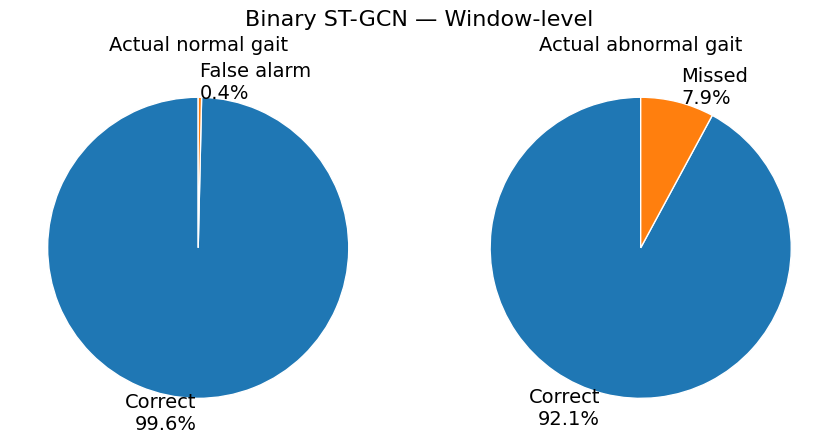

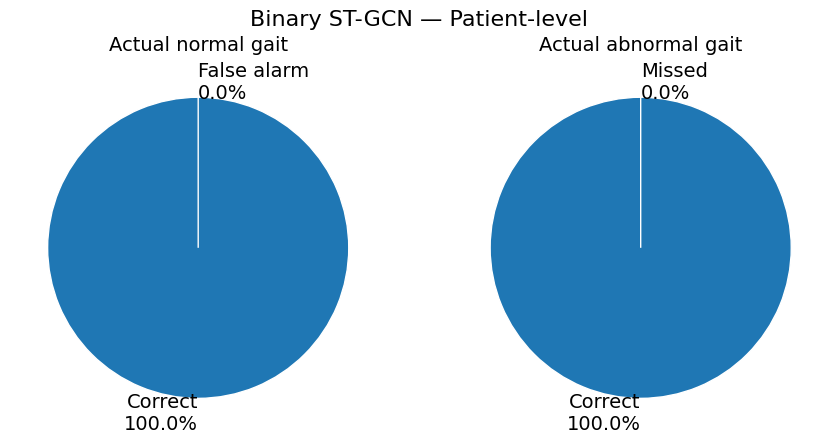


=== Multilabel | Window-level ===
Accuracy: 0.29014084507042254
F1 (macro): 0.11852155208074792
Confusion matrix:
 [[98 69 39 37  8]
 [34  1 14 34  0]
 [ 0  0  0  0  0]
 [12  0  2  4  3]
 [ 0  0  0  0  0]]

=== Multilabel | Patient-level ===
Accuracy: 0.0
F1 (macro): 0.0
Confusion matrix:
 [[0 1 2 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]]


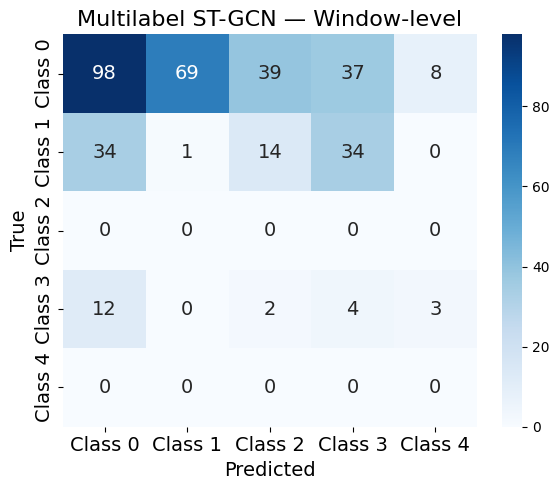

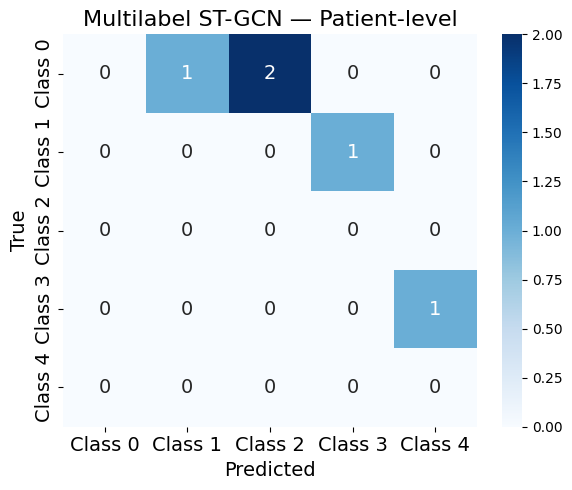

In [183]:
# ============================================================
# FULL FIXED ST-GCN EVALUATION SCRIPT
# ============================================================

import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)

# ============================================================
# Add models folder to path
# ============================================================
sys.path.append("../models")  # adjust if needed
from net.st_gcn import Model
from net.gait14_graph import Graph as GaitGraph

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Model checkpoint paths
# ============================================================
BINARY_MODEL_PATH = Path("../models/binary_stgcn_gait14_improved_stadedict.bin")
MULTI_MODEL_PATH  = Path("../models/multilabel_stgcn_state_dict.bin")

# ============================================================
# Load state_dicts
# ============================================================
binary_state_dict = torch.load(BINARY_MODEL_PATH, map_location=device)
multi_state_dict  = torch.load(MULTI_MODEL_PATH, map_location=device)

# ============================================================
# Plotting helpers
# ============================================================
def plot_out_of_100_pies(cm, title,
                          suptitle_fontsize=16,
                          slice_label_fontsize=14,
                          subplot_title_fontsize=14):
    """
    Pie charts for binary confusion matrix, showing percentages out of 100.
    """
    normal_row = cm[0] / cm[0].sum()
    abnormal_row = cm[1] / cm[1].sum()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(title, fontsize=suptitle_fontsize)

    # Actual normal
    axes[0].pie(
        [normal_row[0]*100, normal_row[1]*100],
        labels=[f"Correct\n{normal_row[0]*100:.1f}%", f"False alarm\n{normal_row[1]*100:.1f}%"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[0].set_title("Actual normal gait", fontsize=subplot_title_fontsize)

    # Actual abnormal
    axes[1].pie(
        [abnormal_row[1]*100, abnormal_row[0]*100],
        labels=[f"Correct\n{abnormal_row[1]*100:.1f}%", f"Missed\n{abnormal_row[0]*100:.1f}%"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[1].set_title("Actual abnormal gait", fontsize=subplot_title_fontsize)

    plt.tight_layout()
    plt.show()


def plot_confusion_heatmap(cm, title, class_names,
                           title_fontsize=16,
                           label_fontsize=14,
                           tick_fontsize=14):
    """
    Heatmap for confusion matrix using seaborn, with adjustable font sizes.
    """
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"fontsize": label_fontsize}  # annotation inside cells
    )
    plt.xlabel("Predicted", fontsize=label_fontsize)
    plt.ylabel("True", fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.title(title, fontsize=title_fontsize)
    plt.tight_layout()
    plt.show()


# ============================================================
# Dataset wrapper
# ============================================================
class GaitDataset(Dataset):
    def __init__(self, X, y, patient_names=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32 if len(y.shape) > 1 else torch.long)
        self.pids = np.array(patient_names) if patient_names is not None else np.arange(len(y))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.pids[idx]

# ============================================================
# Assume X_clean, y_binary_clean, y_multilabel_clean, patient_names_clean are defined
# X_clean shape: (N_windows, T, 14, 3)
# ============================================================

# -------------------------------
# Patient-level train/test split
# -------------------------------
from sklearn.model_selection import train_test_split
unique_patients = np.unique(patient_names_clean)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

train_mask = np.isin(patient_names_clean, train_patients)
test_mask  = np.isin(patient_names_clean, test_patients)

# Apply masks
X_train = X_clean[train_mask]
X_test  = X_clean[test_mask]
y_bin_train = y_binary_clean[train_mask]
y_bin_test  = y_binary_clean[test_mask]
y_ml_train  = y_multilabel_clean[train_mask]
y_ml_test   = y_multilabel_clean[test_mask]
patient_train = patient_names_clean[train_mask]
patient_test  = patient_names_clean[test_mask]

print(f"Train windows: {X_train.shape[0]}, Test windows: {X_test.shape[0]}")

# -------------------------------
# Transpose to ST-GCN format: (N, C=3, T, V), add M=1 dimension
# -------------------------------
X_train_stgcn = X_train.transpose(0, 3, 1, 2)[..., np.newaxis]  # (N, 3, T, 14, 1)
X_test_stgcn  = X_test.transpose(0, 3, 1, 2)[..., np.newaxis]

# -------------------------------
# Create DataLoaders
# -------------------------------
batch_size = 32

# Binary
train_dataset_bin = GaitDataset(X_train_stgcn, y_bin_train, patient_train)
test_dataset_bin  = GaitDataset(X_test_stgcn, y_bin_test, patient_test)
train_loader_bin = DataLoader(train_dataset_bin, batch_size=batch_size, shuffle=True)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=batch_size, shuffle=False)

# Multilabel (only abnormal windows)
abnormal_mask_train = y_bin_train == 1
abnormal_mask_test  = y_bin_test == 1
X_ml_train_stgcn = X_train_stgcn[abnormal_mask_train]
y_ml_train_filtered = y_ml_train[abnormal_mask_train]
patient_ml_train = patient_train[abnormal_mask_train]

X_ml_test_stgcn = X_test_stgcn[abnormal_mask_test]
y_ml_test_filtered = y_ml_test[abnormal_mask_test]
patient_ml_test = patient_test[abnormal_mask_test]

train_dataset_ml = GaitDataset(X_ml_train_stgcn, y_ml_train_filtered, patient_ml_train)
test_dataset_ml  = GaitDataset(X_ml_test_stgcn, y_ml_test_filtered, patient_ml_test)
train_loader_ml = DataLoader(train_dataset_ml, batch_size=batch_size, shuffle=True)
test_loader_ml  = DataLoader(test_dataset_ml, batch_size=batch_size, shuffle=False)

# ============================================================
# BINARY ST-GCN
# ============================================================
binary_stgcn = Model(
    in_channels=3,
    num_class=1,
    edge_importance_weighting=True,
    graph_args={}
).to(device)
binary_stgcn.load_state_dict(binary_state_dict)
binary_stgcn.eval()

all_probs, all_targets, all_patients = [], [], []

with torch.no_grad():
    for X_batch, y_batch, pids in test_loader_bin:
        X_batch = X_batch.to(device)
        logits = binary_stgcn(X_batch).squeeze(1)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())
        all_patients.append(np.array(pids))

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_patients = np.concatenate(all_patients)

window_preds = (all_probs > 0.5).astype(int)
cm_window_bin = confusion_matrix(all_targets, window_preds)

print("\n=== Binary | Window-level ===")
print("Accuracy:", accuracy_score(all_targets, window_preds))
print("F1:", f1_score(all_targets, window_preds))
print("Precision:", precision_score(all_targets, window_preds))
print("Recall:", recall_score(all_targets, window_preds))
print("AUROC:", roc_auc_score(all_targets, all_probs))
print("Confusion matrix:\n", cm_window_bin)

# Patient-level
unique_patients = np.unique(all_patients)
patient_preds, patient_probs, patient_true = [], [], []

for pid in unique_patients:
    mask = all_patients == pid
    patient_preds.append(int(np.round(window_preds[mask].mean())))
    patient_probs.append(all_probs[mask].max())
    patient_true.append(int(np.round(all_targets[mask].mean())))

patient_preds = np.array(patient_preds)
patient_probs = np.array(patient_probs)
patient_true  = np.array(patient_true)
cm_patient_bin = confusion_matrix(patient_true, patient_preds)

print("\n=== Binary | Patient-level ===")
print("Accuracy:", accuracy_score(patient_true, patient_preds))
print("F1:", f1_score(patient_true, patient_preds))
print("Precision:", precision_score(patient_true, patient_preds))
print("Recall:", recall_score(patient_true, patient_preds))
print("AUROC:", roc_auc_score(patient_true, patient_probs))
print("Confusion matrix:\n", cm_patient_bin)

plot_out_of_100_pies(cm_window_bin, "Binary ST-GCN — Window-level")
plot_out_of_100_pies(cm_patient_bin, "Binary ST-GCN — Patient-level")

# ============================================================
# MULTILABEL ST-GCN
# ============================================================
num_classes = y_ml_train_filtered.shape[1]
class_names = [f"Class {i}" for i in range(num_classes)]

multilabel_stgcn = Model(
    in_channels=3,
    num_class=num_classes,
    edge_importance_weighting=True,
    graph_args={}
).to(device)
multilabel_stgcn.load_state_dict(multi_state_dict)
multilabel_stgcn.eval()

all_probs, all_targets, all_patients = [], [], []

with torch.no_grad():
    for X_batch, y_batch, pids in test_loader_ml:
        X_batch = X_batch.to(device)
        logits = multilabel_stgcn(X_batch)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())
        all_patients.append(np.array(pids))

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_patients = np.concatenate(all_patients)

# Window-level
window_preds = (all_probs > 0.5).astype(int)
y_true_win = all_targets.argmax(axis=1)
y_pred_win = window_preds.argmax(axis=1)
cm_window_ml = confusion_matrix(y_true_win, y_pred_win)

print("\n=== Multilabel | Window-level ===")
print("Accuracy:", accuracy_score(y_true_win, y_pred_win))
print("F1 (macro):", f1_score(y_true_win, y_pred_win, average="macro"))
print("Confusion matrix:\n", cm_window_ml)

# Patient-level
unique_patients = np.unique(all_patients)
patient_true, patient_preds = [], []

for pid in unique_patients:
    mask = all_patients == pid
    avg_probs = all_probs[mask].mean(axis=0)
    patient_preds.append(avg_probs.argmax())
    patient_true.append(all_targets[mask][0].argmax())

patient_true = np.array(patient_true)
patient_preds = np.array(patient_preds)
cm_patient_ml = confusion_matrix(patient_true, patient_preds)

print("\n=== Multilabel | Patient-level ===")
print("Accuracy:", accuracy_score(patient_true, patient_preds))
print("F1 (macro):", f1_score(patient_true, patient_preds, average="macro"))
print("Confusion matrix:\n", cm_patient_ml)

plot_confusion_heatmap(cm_window_ml, "Multilabel ST-GCN — Window-level", class_names)
plot_confusion_heatmap(cm_patient_ml, "Multilabel ST-GCN — Patient-level", class_names)


In [179]:
def plot_out_of_100_pies(cm, title,
                          suptitle_fontsize=16,
                          slice_label_fontsize=14,
                          subplot_title_fontsize=14):
    """
    Pie charts for binary confusion matrix, showing percentages out of 100.
    Plots one above the other (vertical layout).
    """
    normal_row = cm[0] / cm[0].sum()
    abnormal_row = cm[1] / cm[1].sum()

    # Change layout to 2 rows, 1 column
    fig, axes = plt.subplots(2, 1, figsize=(6, 9))
    fig.suptitle(title, fontsize=suptitle_fontsize)

    # Actual normal
    axes[0].pie(
        [normal_row[0]*100, normal_row[1]*100],
        labels=[f"Correct\n{normal_row[0]*100:.1f}%", f"False alarm\n{normal_row[1]*100:.1f}%"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[0].set_title("Actual normal gait", fontsize=subplot_title_fontsize)

    # Actual abnormal
    axes[1].pie(
        [abnormal_row[1]*100, abnormal_row[0]*100],
        labels=[f"Correct\n{abnormal_row[1]*100:.1f}%", f"Missed\n{abnormal_row[0]*100:.1f}%"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[1].set_title("Actual abnormal gait", fontsize=subplot_title_fontsize)

    plt.tight_layout()
    plt.show()


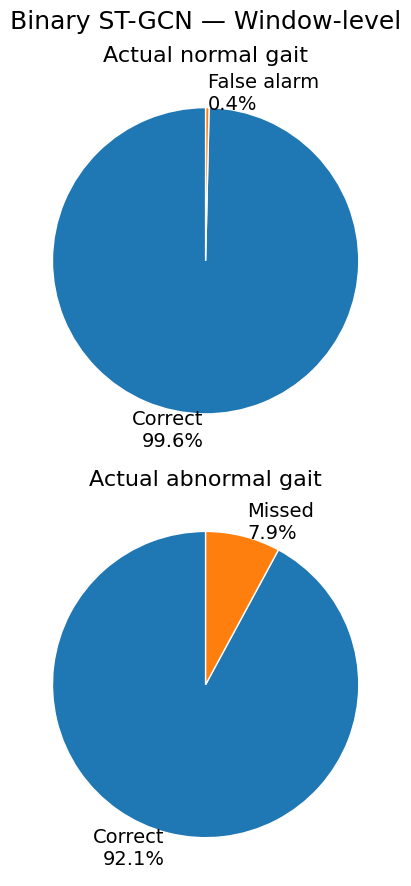

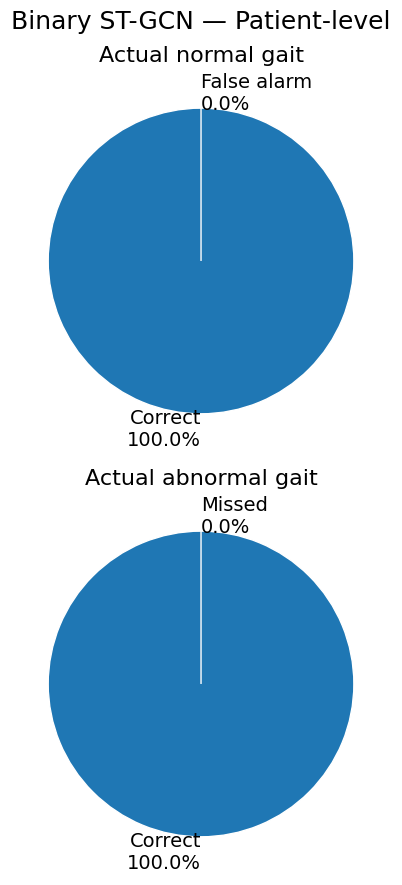

In [180]:
# Window-level binary confusion matrix
plot_out_of_100_pies(
    cm_window_bin, 
    title="Binary ST-GCN — Window-level",
    suptitle_fontsize=18,
    slice_label_fontsize=14,
    subplot_title_fontsize=16
)

# Patient-level binary confusion matrix
plot_out_of_100_pies(
    cm_patient_bin, 
    title="Binary ST-GCN — Patient-level",
    suptitle_fontsize=18,
    slice_label_fontsize=14,
    subplot_title_fontsize=16
)


In [196]:
def plot_out_of_100_pies(cm, title,
                          suptitle_fontsize=16,
                          slice_label_fontsize=14,
                          subplot_title_fontsize=14):
    """
    Pie charts for binary confusion matrix, showing percentages out of 100.
    Green = correct, Red = incorrect
    """
    normal_row = cm[0] / cm[0].sum()
    abnormal_row = cm[1] / cm[1].sum()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))  # horizontal alignment
    fig.suptitle(title, fontsize=suptitle_fontsize)

    # Actual normal
    axes[0].pie(
        [normal_row[0]*100, normal_row[1]*100],
        labels=[f"Correct\n{normal_row[0]*100:.1f}%", 
                f"False alarm\n{normal_row[1]*100:.1f}%"],
        colors=["green", "red"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[0].set_title("Actual normal gait", fontsize=subplot_title_fontsize)

    # Actual abnormal
    axes[1].pie(
        [abnormal_row[1]*100, abnormal_row[0]*100],
        labels=[f"Correct\n{abnormal_row[1]*100:.1f}%", 
                f"Missed\n{abnormal_row[0]*100:.1f}%"],
        colors=["green", "red"],
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": slice_label_fontsize}
    )
    axes[1].set_title("Actual abnormal gait", fontsize=subplot_title_fontsize)

    plt.tight_layout()
    plt.show()


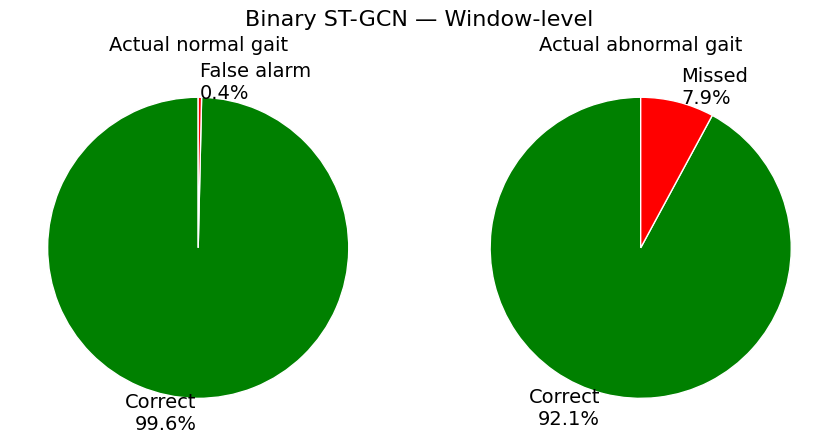

In [197]:
plot_out_of_100_pies(cm_window_bin, "Binary ST-GCN — Window-level")

In [184]:
def plot_confusion_matrix_custom_colors(cm, 
                                        class_names=("Normal", "Abnormal"), 
                                        title="Confusion Matrix",
                                        title_fontsize=16,
                                        label_fontsize=14,
                                        axis_label_fontsize=14,
                                        tick_fontsize=14):
    """
    Confusion matrix with custom colors per cell:
    Top-left → yellow, Top-right → red, Bottom-left → purple, Bottom-right → pink
    Automatically adds counts and percentages per row.
    Font sizes can be adjusted with title_fontsize, label_fontsize, axis_label_fontsize, tick_fontsize.
    """
    cm = np.asarray(cm)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = cm / np.maximum(row_sums, 1)  # avoid divide-by-zero

    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    # Define cell colors manually
    cell_colors = np.array([["yellow", "red"],
                            ["purple", "pink"]])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=cell_colors[i, j]))

    # Set limits, ticks, labels
    ax.set_xlim(-0.5, cm.shape[1]-0.5)
    ax.set_ylim(-0.5, cm.shape[0]-0.5)
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    ax.set_xticklabels(class_names, fontsize=tick_fontsize)
    ax.set_yticklabels(class_names, fontsize=tick_fontsize)
    ax.set_xlabel("Predicted", fontsize=axis_label_fontsize)
    ax.set_ylabel("Actual", fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    ax.invert_yaxis()  # origin at top-left

    # Add cell annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            pct = row_pct[i, j] * 100

            if i == 0 and j == 0:
                label = "Correct normal"
            elif i == 0 and j == 1:
                label = "False alarm\n(normal→abnormal)"
            elif i == 1 and j == 0:
                label = "Missed abnormal\n(abnormal→normal)"
            else:
                label = "Correct abnormal"

            text_color = "black" if cell_colors[i, j] in ["yellow", "pink"] else "white"
            ax.text(j, i, f"{label}\n{count} ({pct:.1f}%)",
                    ha="center", va="center", fontsize=label_fontsize, color=text_color)

    # Draw gridlines
    ax.set_xticks(np.arange(-.5, cm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, cm.shape[0], 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, color="gray")
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    return fig, ax


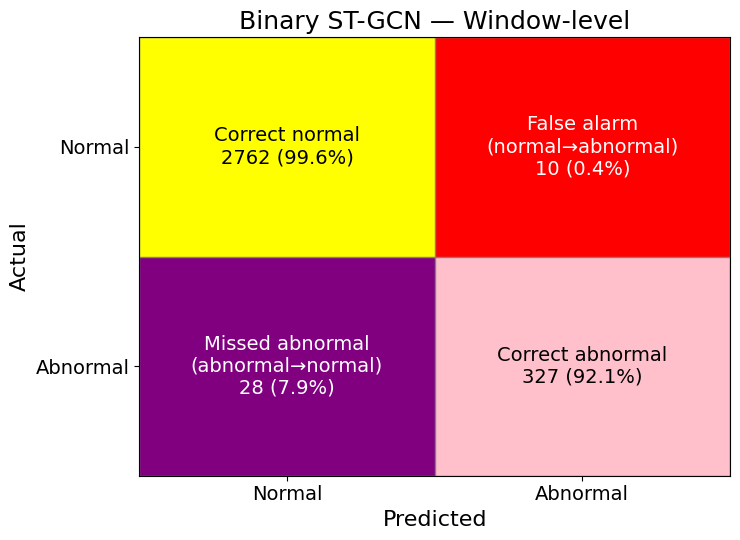

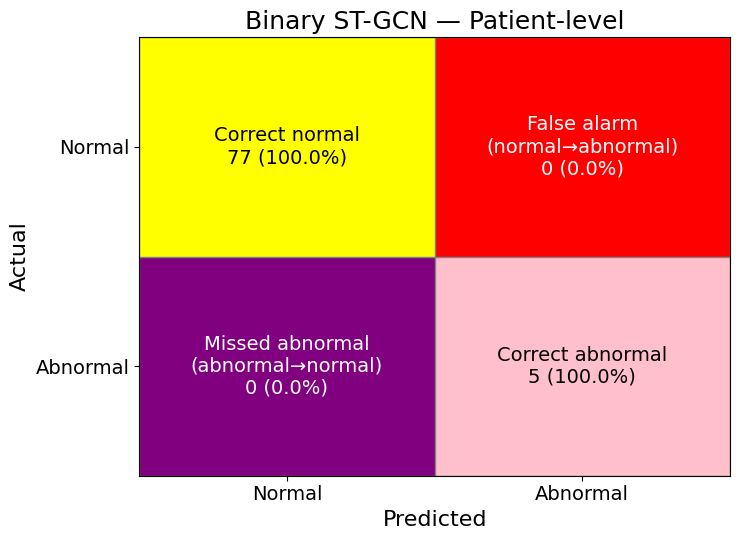

In [185]:
# Window-level binary
plot_confusion_matrix_custom_colors(cm_window_bin, class_names=["Normal", "Abnormal"],
                                    title="Binary ST-GCN — Window-level",
                                    title_fontsize=18,
                                    label_fontsize=14,
                                    axis_label_fontsize=16,
                                    tick_fontsize=14)
plt.show()

# Patient-level binary
plot_confusion_matrix_custom_colors(cm_patient_bin, class_names=["Normal", "Abnormal"],
                                    title="Binary ST-GCN — Patient-level",
                                    title_fontsize=18,
                                    label_fontsize=14,
                                    axis_label_fontsize=16,
                                    tick_fontsize=14)
plt.show()


In [186]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_confusion_matrix_custom(cm, 
                                 class_names=None, 
                                 title="Confusion Matrix",
                                 title_fontsize=18,
                                 label_fontsize=14,
                                 axis_label_fontsize=16,
                                 tick_fontsize=14):
    """
    Plot a confusion matrix with:
    - Binary (2x2): top-left yellow, top-right red, bottom-left purple, bottom-right pink
    - Multi-class (>2x2): gradient from light to dark blue
    All font sizes are adjustable.
    """
    cm = np.asarray(cm)
    num_classes = cm.shape[0]

    # Row percentages
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = cm / np.maximum(row_sums, 1)  # avoid divide-by-zero

    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    if num_classes == 2:
        # Binary custom colors
        cell_colors = np.array([["yellow", "red"],
                                ["purple", "pink"]])
        for i in range(2):
            for j in range(2):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=cell_colors[i, j]))

        # Add text inside each cell
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                pct = row_pct[i, j] * 100
                if i == 0 and j == 0:
                    label_text = "Correct normal"
                elif i == 0 and j == 1:
                    label_text = "False alarm\n(normal→abnormal)"
                elif i == 1 and j == 0:
                    label_text = "Missed abnormal\n(abnormal→normal)"
                else:
                    label_text = "Correct abnormal"
                text_color = "black" if cell_colors[i, j] in ["yellow", "pink"] else "white"
                ax.text(j, i, f"{label_text}\n{count} ({pct:.1f}%)",
                        ha="center", va="center", fontsize=label_fontsize, color=text_color)
    else:
        # Multi-class (>2)
        cmap = plt.cm.Blues
        for i in range(num_classes):
            for j in range(num_classes):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                           facecolor=cmap(row_pct[i, j]),
                                           edgecolor='white'))
                count = cm[i, j]
                pct = row_pct[i, j] * 100
                ax.text(j, i, f"{count}\n({pct:.1f}%)", 
                        ha="center", va="center", fontsize=label_fontsize,
                        color="white" if row_pct[i, j] > 0.5 else "black")

    # Axes and labels
    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
    ax.set_xlim(-0.5, num_classes - 0.5)
    ax.set_ylim(-0.5, num_classes - 0.5)
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, fontsize=tick_fontsize)
    ax.set_yticklabels(class_names, fontsize=tick_fontsize)
    ax.set_xlabel("Predicted", fontsize=axis_label_fontsize)
    ax.set_ylabel("Actual", fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    ax.invert_yaxis()  # origin at top-left

    # Gridlines
    ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
    ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, color="gray")
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    return fig, ax


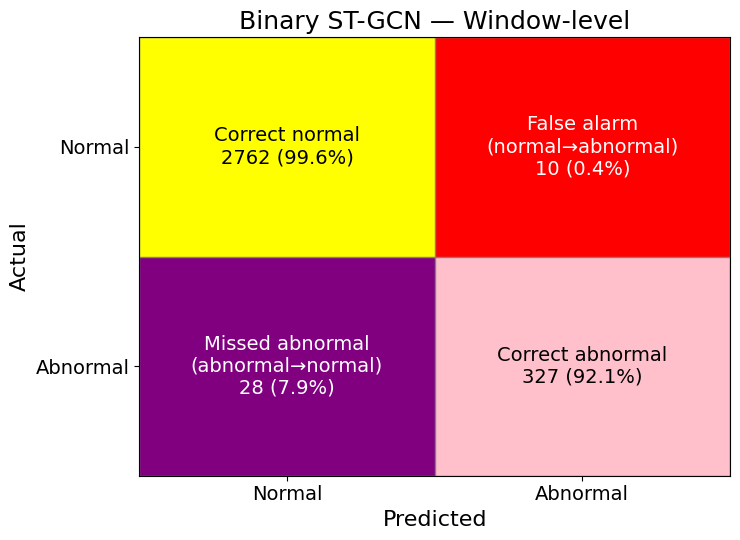

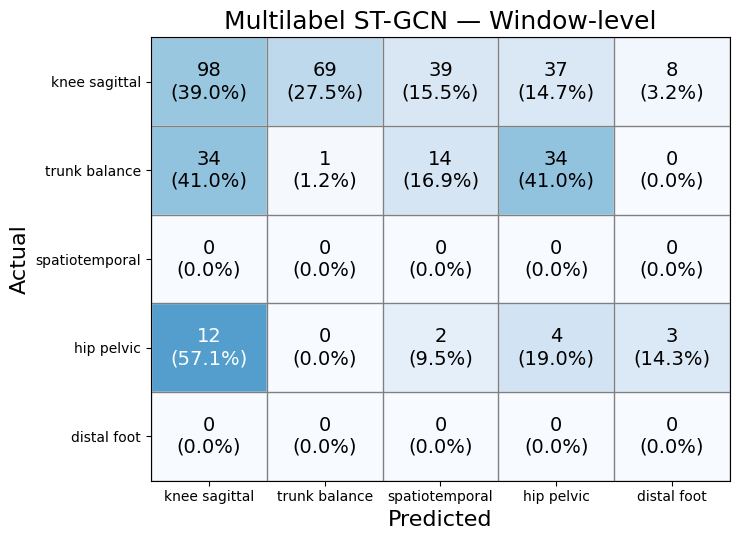

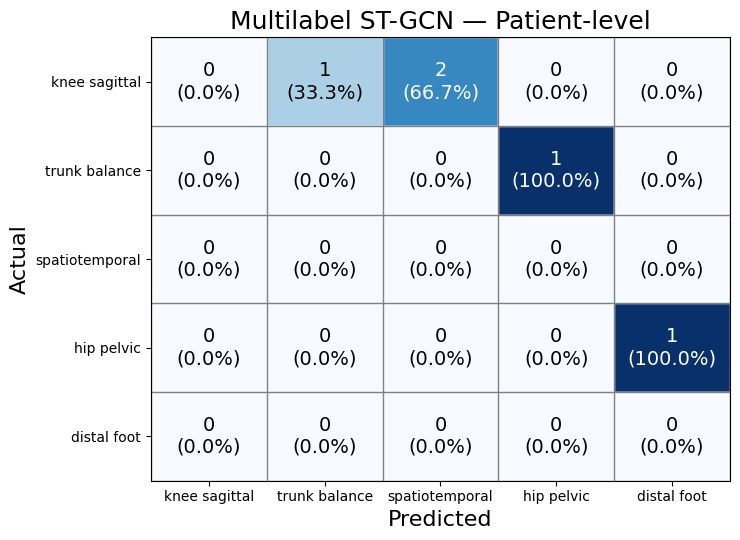

In [187]:
ANOMALY_LABELS = [
    "knee sagittal",
    "trunk balance",
    "spatiotemporal",
    "hip pelvic",
    "distal foot"
]

# Binary
plot_confusion_matrix_custom(cm_window_bin, class_names=["Normal","Abnormal"],
                             title="Binary ST-GCN — Window-level",
                             title_fontsize=18, label_fontsize=14, axis_label_fontsize=16, tick_fontsize=14)
plt.show()

# Multi-class
plot_confusion_matrix_custom(cm_window_ml, class_names=ANOMALY_LABELS,
                             title="Multilabel ST-GCN — Window-level",
                             title_fontsize=18, label_fontsize=14, axis_label_fontsize=16, tick_fontsize=10)
plt.show()

plot_confusion_matrix_custom(cm_patient_ml, class_names=ANOMALY_LABELS,
                             title="Multilabel ST-GCN — Patient-level",
                             title_fontsize=18, label_fontsize=14, axis_label_fontsize=16, tick_fontsize=10)
plt.show()


In [169]:
def plot_confusion_matrix_custom(cm, class_names=None, title="Confusion Matrix",
                                 title_fontsize=16, label_fontsize=14, tick_fontsize=12):
    """
    Confusion matrix with custom colors (binary) or gradient (multi-class)
    """
    cm = np.asarray(cm)
    num_classes = cm.shape[0]

    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = cm / np.maximum(row_sums, 1)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))

    if num_classes == 2:
        # Binary custom colors (4 colors)
        cell_colors = np.array([["yellow", "red"],
                                ["purple", "pink"]])
        for i in range(2):
            for j in range(2):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=cell_colors[i, j]))
                count = cm[i, j]
                pct = row_pct[i, j] * 100
                if i == 0 and j == 0: label_text = "Correct normal"
                elif i == 0 and j == 1: label_text = "False alarm\n(normal→abnormal)"
                elif i == 1 and j == 0: label_text = "Missed abnormal\n(abnormal→normal)"
                else: label_text = "Correct abnormal"
                text_color = "black" if cell_colors[i, j] in ["yellow", "pink"] else "white"
                ax.text(j, i, f"{label_text}\n{count} ({pct:.1f}%)",
                        ha="center", va="center", fontsize=label_fontsize, color=text_color)
    else:
        # Multi-class gradient
        cmap = plt.cm.Blues
        for i in range(num_classes):
            for j in range(num_classes):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                           facecolor=cmap(row_pct[i, j]),
                                           edgecolor='white'))
                count = cm[i, j]
                pct = row_pct[i, j] * 100
                ax.text(j, i, f"{count}\n({pct:.1f}%)",
                        ha="center", va="center",
                        fontsize=label_fontsize,
                        color="white" if row_pct[i, j] > 0.5 else "black")

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
    ax.set_xlim(-0.5, num_classes - 0.5)
    ax.set_ylim(-0.5, num_classes - 0.5)
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, fontsize=tick_fontsize)
    ax.set_yticklabels(class_names, fontsize=tick_fontsize)
    ax.set_xlabel("Predicted", fontsize=label_fontsize)
    ax.set_ylabel("Actual", fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    ax.invert_yaxis()

    ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
    ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, color="gray")
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    return fig, ax


def plot_multiclass_pie(cm, class_names=None, title="Multi-class Breakdown",
                        label_fontsize=12, title_fontsize=16, subplot_title_fontsize=14):
    """
    Pie charts for multi-class confusion matrix.
    """
    cm = np.asarray(cm)
    num_classes = cm.shape[0]

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    fig, axes = plt.subplots(1, num_classes, figsize=(4*num_classes, 4))
    if num_classes == 1:
        axes = [axes]

    for i in range(num_classes):
        correct = cm[i, i]
        incorrect = cm[i].sum() - correct

        if correct + incorrect == 0:
            axes[i].pie([1], labels=["No samples"], colors=["lightgray"], startangle=90,
                        textprops={"fontsize": label_fontsize})
        else:
            axes[i].pie([correct, incorrect],
                        labels=[f"Correct\n{correct} ({correct/cm[i].sum()*100:.1f}%)",
                                f"Misclassified\n{incorrect} ({incorrect/cm[i].sum()*100:.1f}%)"],
                        startangle=90,
                        colors=["green", "red"],
                        wedgeprops={"edgecolor": "white"},
                        textprops={"fontsize": label_fontsize})
        axes[i].set_title(class_names[i], fontsize=subplot_title_fontsize)

    plt.suptitle(title, fontsize=title_fontsize)
    plt.tight_layout()
    plt.show()


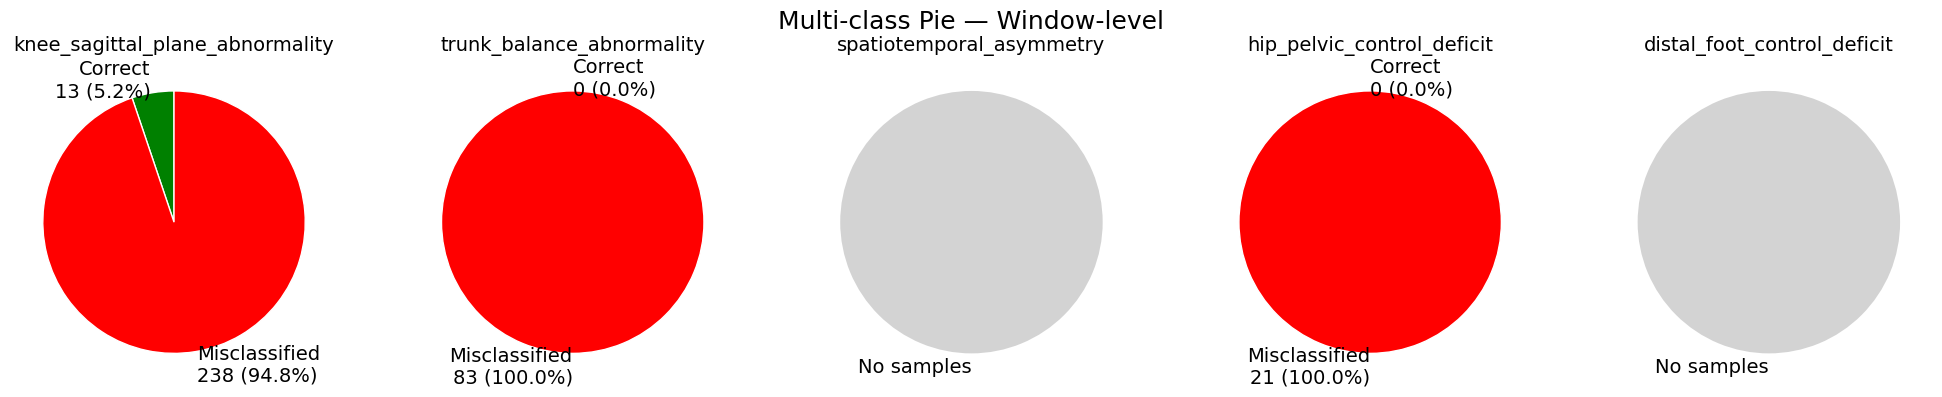

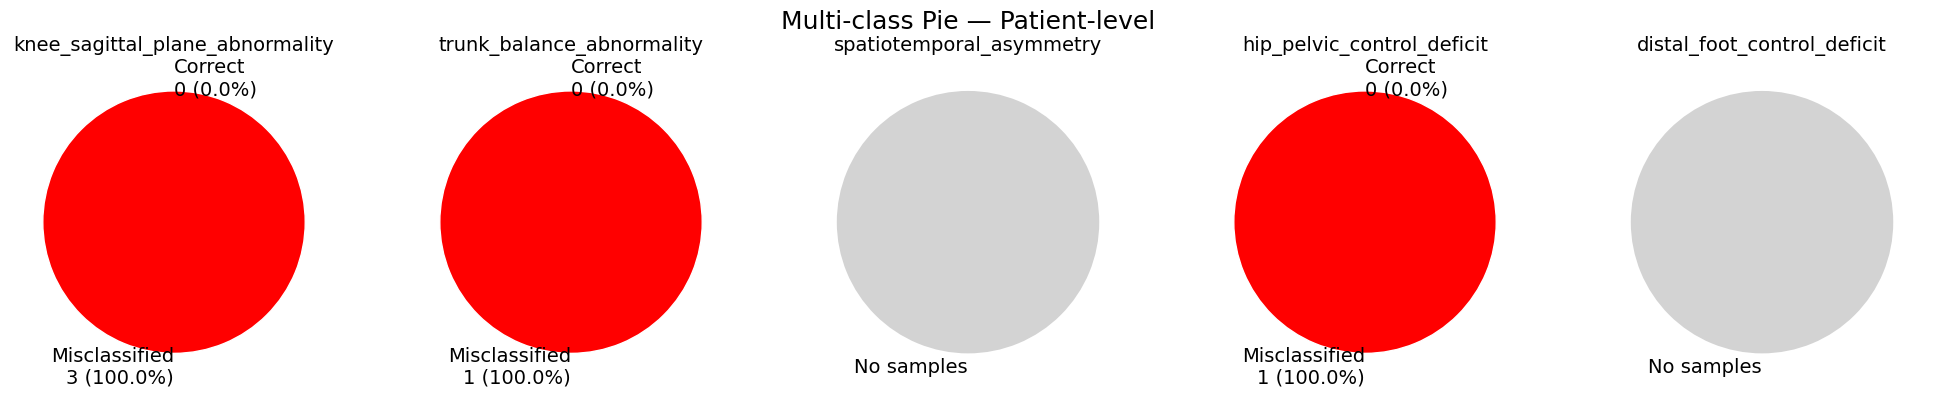

In [170]:
ANOMALY_COLSb = [
    "knee_sagittal_plane_abnormality",
    "trunk_balance_abnormality",
    "spatiotemporal_asymmetry",
    "hip_pelvic_control_deficit",
    "distal_foot_control_deficit"
]


# Window-level multi-class
plot_multiclass_pie(cm_window_ml, class_names=ANOMALY_COLSb,
                    title="Multi-class Pie — Window-level",
                    label_fontsize=14, title_fontsize=18)

# Patient-level multi-class
plot_multiclass_pie(cm_patient_ml, class_names=ANOMALY_COLSb,
                    title="Multi-class Pie — Patient-level",
                    label_fontsize=14, title_fontsize=18)


In [33]:
print(ANOMALY_COLS)

['gait_anomaly_knee_sagittal_plane_abnormality', 'gait_anomaly_trunk_balance_abnormality', 'gait_anomaly_spatiotemporal_asymmetry', 'gait_anomaly_hip_pelvic_control_deficit', 'gait_anomaly_distal_foot_control_deficit']


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multiclass_single_pie_safe(cm, class_names, title="Multi-class Pie"):
    """
    Plot one pie chart summarizing correct predictions per class
    Handles empty confusion matrices safely.
    """
    cm = np.asarray(cm)
    if cm.shape[0] != len(class_names):
        raise ValueError("Number of class names must match confusion matrix size")

    # Correct predictions per class (diagonal)
    correct_counts = cm.diagonal()
    total_counts = correct_counts.sum()
    
    if total_counts == 0:
        print(f"Warning: No correct predictions in {title}. Pie chart cannot be drawn.")
        return

    # Only include classes with non-zero correct counts
    nonzero_idx = correct_counts > 0
    correct_counts = correct_counts[nonzero_idx]
    labels = [class_names[i] for i in range(len(class_names)) if nonzero_idx[i]]
    percents = 100 * correct_counts / total_counts

    # Plot
    fig, ax = plt.subplots(figsize=(7,7))
    ax.pie(
        correct_counts,
        labels=[f"{lbl}\n{pct:.1f}%" for lbl, pct in zip(labels, percents)],
        startangle=90,
        colors=plt.cm.tab20.colors[:len(correct_counts)],
        wedgeprops={"edgecolor":"white"}
    )
    ax.set_title(title, fontsize=16)
    plt.tight_layout()
    plt.show()


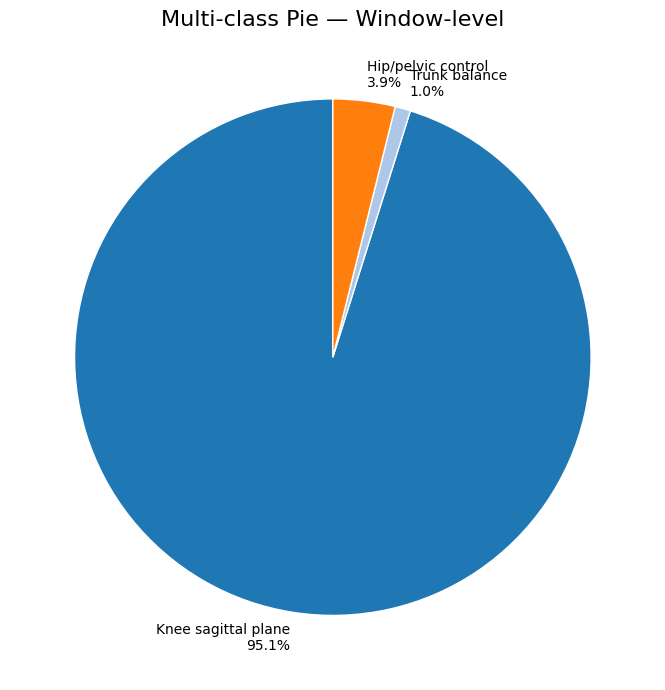

In [39]:
ANOMALY_LABELS = [
    "Knee sagittal plane",
    "Trunk balance",
    "Spatiotemporal asymmetry",
    "Hip/pelvic control",
    "Distal foot control"
]

# Window-level
plot_multiclass_single_pie_safe(cm_window_ml, class_names=ANOMALY_LABELS,
                                title="Multi-class Pie — Window-level")

# Patient-level
plot_multiclass_single_pie_safe(cm_patient_ml, class_names=ANOMALY_LABELS,
                                title="Multi-class Pie — Patient-level")


In [44]:
def plot_multiclass_correct_vs_incorrect(cm, class_names, title="Multi-class Pie",
                                         label_fontsize=12, title_fontsize=16):
    """
    Plot a single pie chart showing correct vs incorrect predictions per class.
    Green = correct, Red = misclassified.
    Skips classes with zero predictions.
    """
    cm = np.asarray(cm)
    num_classes = len(class_names)
    if cm.shape[0] != num_classes:
        raise ValueError("Number of class names must match confusion matrix size")
    
    correct_counts = cm.diagonal()
    total_counts = cm.sum(axis=1)
    incorrect_counts = total_counts - correct_counts

    # Keep only classes with at least one prediction
    nonzero_idx = total_counts > 0
    if nonzero_idx.sum() == 0:
        print(f"Warning: no predictions available for {title}. Pie chart cannot be drawn.")
        return

    labels = [class_names[i] for i in range(num_classes) if nonzero_idx[i]]
    correct = correct_counts[nonzero_idx]
    incorrect = incorrect_counts[nonzero_idx]

    sizes = []
    colors = []
    pie_labels = []
    for i in range(len(labels)):
        sizes.extend([correct[i], incorrect[i]])
        colors.extend(["green", "red"])
        pie_labels.extend([f"{labels[i]} correct", f"{labels[i]} incorrect"])

    if sum(sizes) == 0:
        print(f"Warning: all counts zero for {title}. Pie chart cannot be drawn.")
        return

    fig, ax = plt.subplots(figsize=(8,8))
    wedges, texts = ax.pie(
        sizes,
        labels=pie_labels,
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor":"white"}
    )

    # Set label font size
    for text in texts:
        text.set_fontsize(label_fontsize)

    ax.set_title(title, fontsize=title_fontsize)
    plt.tight_layout()
    plt.show()


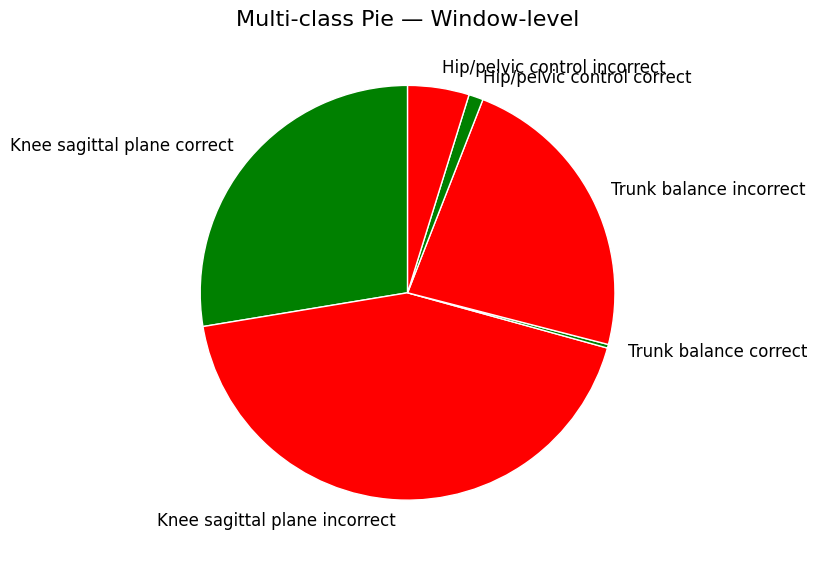

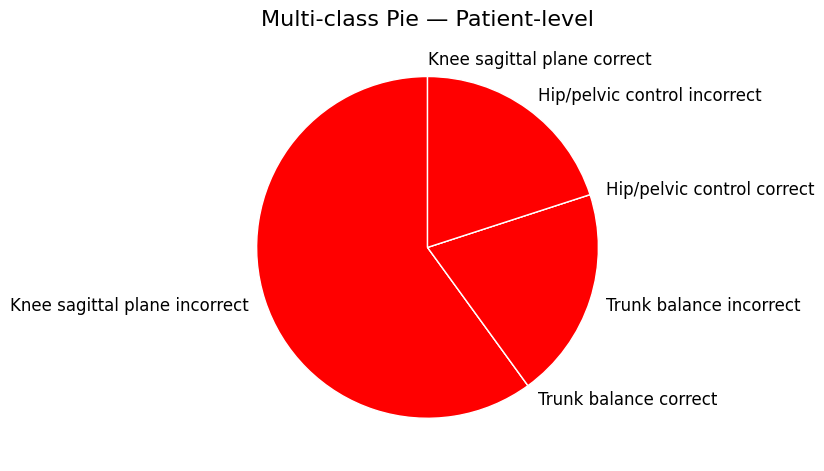

In [45]:
ANOMALY_LABELS = [
    "Knee sagittal plane",
    "Trunk balance",
    "Spatiotemporal asymmetry",
    "Hip/pelvic control",
    "Distal foot control"
]

# Window-level
plot_multiclass_correct_vs_incorrect(cm_window_ml, class_names=ANOMALY_LABELS,
                                     title="Multi-class Pie — Window-level",
                                     label_fontsize=12, title_fontsize=16)

# Patient-level
plot_multiclass_correct_vs_incorrect(cm_patient_ml, class_names=ANOMALY_LABELS,
                                     title="Multi-class Pie — Patient-level",
                                     label_fontsize=12, title_fontsize=16)

In [57]:
def plot_multiclass_correct_vs_incorrect(cm, class_names, title="Multi-class Pie",
                                         label_fontsize=12, title_fontsize=16):
    """
    Plot a single pie chart showing correct vs incorrect predictions per class.
    Green = correct, Red = misclassified.
    Skips classes with zero predictions.
    Labels are placed outside to avoid overlap.
    """
    cm = np.asarray(cm)
    num_classes = len(class_names)
    if cm.shape[0] != num_classes:
        raise ValueError("Number of class names must match confusion matrix size")
    
    correct_counts = cm.diagonal()
    total_counts = cm.sum(axis=1)
    incorrect_counts = total_counts - correct_counts

    # Keep only classes with at least one prediction
    nonzero_idx = total_counts > 0
    if nonzero_idx.sum() == 0:
        print(f"Warning: no predictions available for {title}. Pie chart cannot be drawn.")
        return

    labels = [class_names[i] for i in range(num_classes) if nonzero_idx[i]]
    correct = correct_counts[nonzero_idx]
    incorrect = incorrect_counts[nonzero_idx]

    sizes = []
    colors = []
    pie_labels = []
    for i in range(len(labels)):
        sizes.extend([correct[i], incorrect[i]])
        colors.extend(["green", "red"])
        # Split long labels over two lines
        pie_labels.extend([f"{labels[i]}\ncorrect", f"{labels[i]}\nincorrect"])

    if sum(sizes) == 0:
        print(f"Warning: all counts zero for {title}. Pie chart cannot be drawn.")
        return

    fig, ax = plt.subplots(figsize=(8,8))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=pie_labels,
        autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",  # Prozentwerte nur wenn >0
        startangle=90,
        colors=colors,
        wedgeprops={"edgecolor":"white"},
        labeldistance=1.2,     # Abstand der Labels nach außen
        textprops={'fontsize': label_fontsize}
    )

    ax.set_title(title, fontsize=title_fontsize)
    plt.tight_layout()
    plt.show()


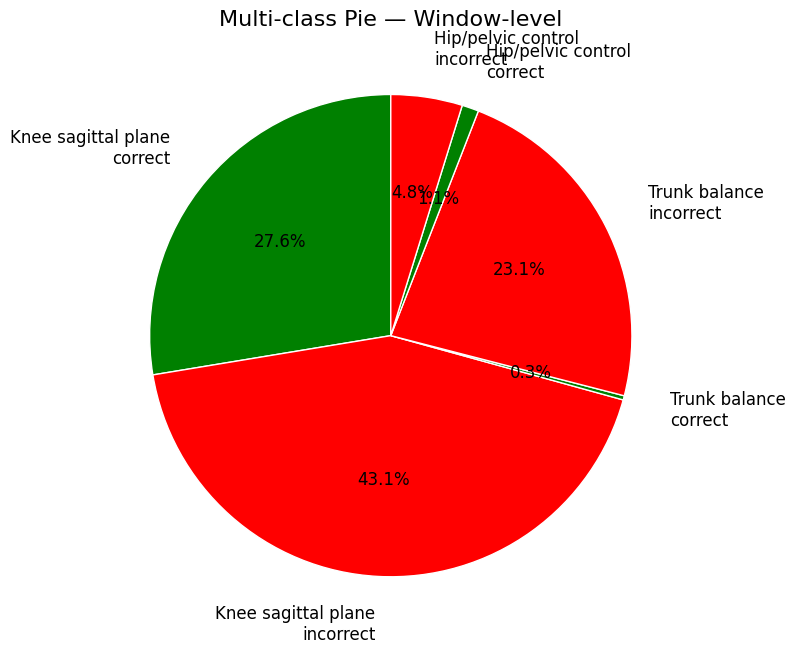

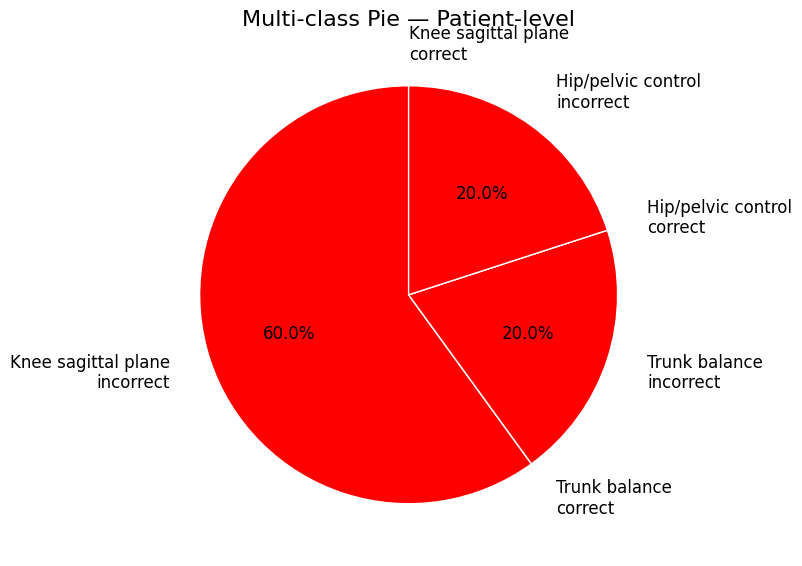

In [58]:
ANOMALY_LABELS = [
    "Knee sagittal plane",
    "Trunk balance",
    "Spatiotemporal asymmetry",
    "Hip/pelvic control",
    "Distal foot control"
]

# Window-level
plot_multiclass_correct_vs_incorrect(cm_window_ml, class_names=ANOMALY_LABELS,
                                     title="Multi-class Pie — Window-level",
                                     label_fontsize=12, title_fontsize=16)

# Patient-level
plot_multiclass_correct_vs_incorrect(cm_patient_ml, class_names=ANOMALY_LABELS,
                                     title="Multi-class Pie — Patient-level",
                                     label_fontsize=12, title_fontsize=16)

In [ ]:
# pie charts with adjustable title and label distances
import numpy as np
import matplotlib.pyplot as plt


def plot_multiclass_pie_separated_labels(
    cm,
    class_names,
    title="Multi-class Pie",
    label_fontsize=16,
    title_fontsize=24,
    correct_radius=1.1,
    incorrect_radius=1.2,
    line_start_radius=0.85
):
    """
    Pie chart showing correct vs incorrect predictions per class.

    - Green = correct
    - Red = incorrect
    - Correct labels closer to the pie
    - Incorrect labels further away
    - Lines connect slices to labels
    - Robust against zero-count classes
    """

    cm = np.asarray(cm)
    num_classes = len(class_names)

    # Counts
    correct = cm.diagonal()
    total = cm.sum(axis=1)
    incorrect = total - correct

    # Build plotting data
    sizes = []
    colors = []
    labels = []
    is_correct_flag = []

    for i in range(num_classes):
        if total[i] == 0:
            continue

        sizes += [correct[i], incorrect[i]]
        colors += ["green", "red"]
        labels += [
            f"{class_names[i]} (correct)",
            f"{class_names[i]} (incorrect)"
        ]
        is_correct_flag += [True, False]   # <-- critical fix

    if sum(sizes) == 0:
        print("No data to plot")
        return

    # Plot pie
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, _ = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )

    # Place labels with independent distances
    for i, w in enumerate(wedges):
        angle = (w.theta1 + w.theta2) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        r_label = correct_radius if is_correct_flag[i] else incorrect_radius
        ha = "left" if x >= 0 else "right"

        ax.text(
            x * r_label,
            y * r_label,
            labels[i],
            ha=ha,
            va="center",
            fontsize=label_fontsize
        )

        # Connector line
        ax.plot(
            [x * line_start_radius, x * r_label],
            [y * line_start_radius, y * r_label],
            color="black",
            lw=0.8
        )

    # Title + layout
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.axis("equal")

    plt.show()


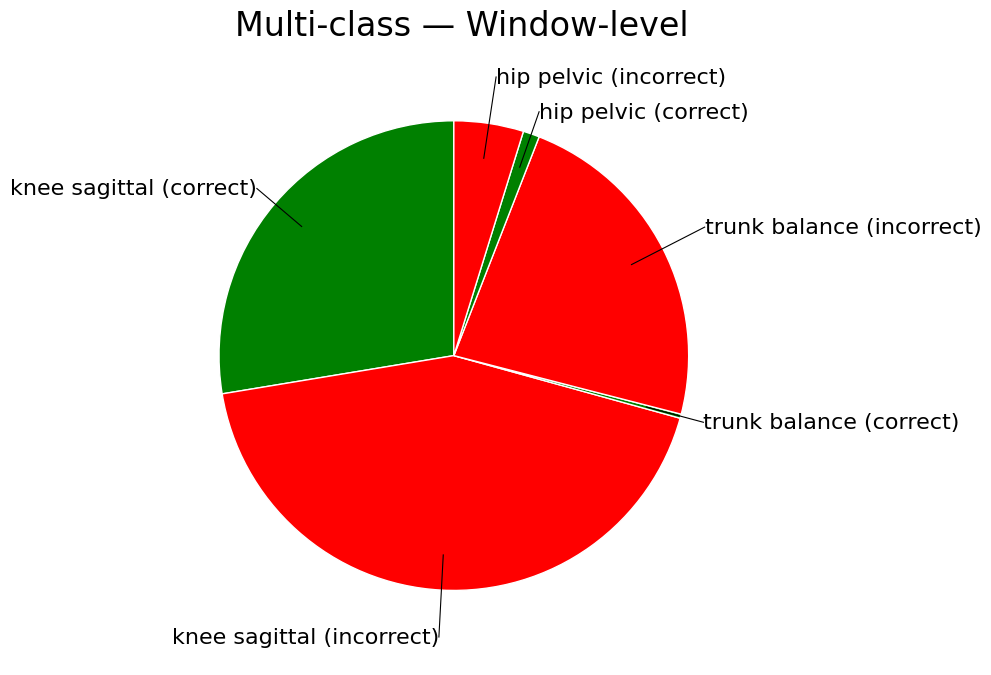

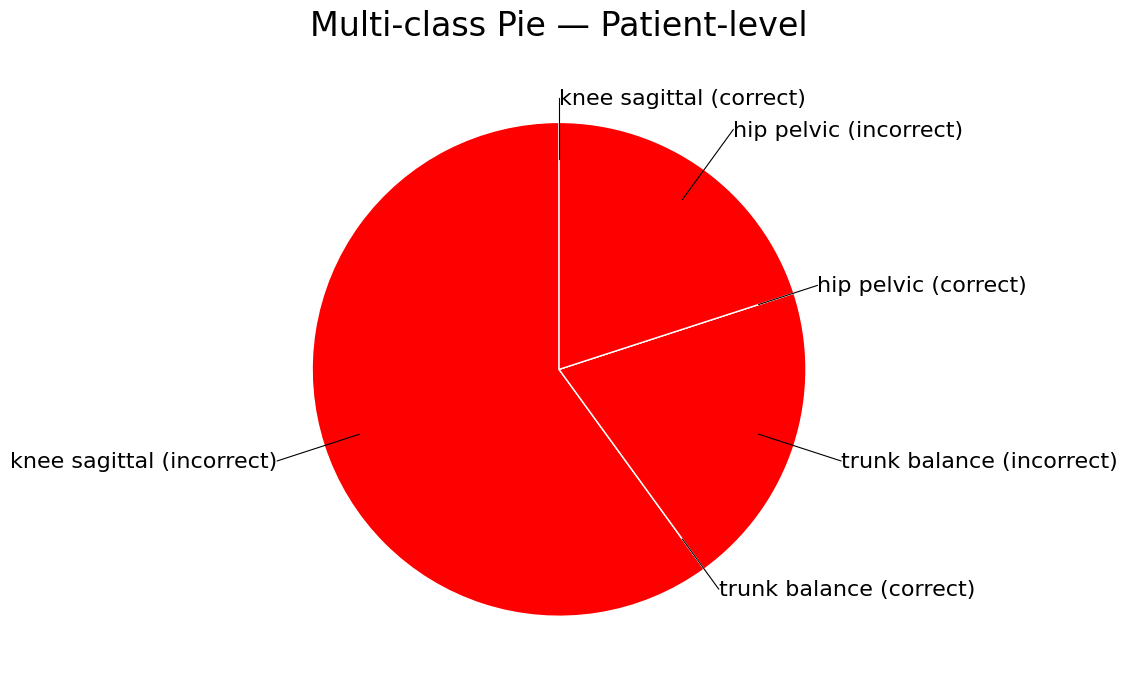

In [153]:
ANOMALY_LABELS = [
    "knee sagittal",
    "trunk balance",
    "spatiotemporal",
    "hip pelvic",
    "distal foot"
]

plot_multiclass_pie_separated_labels(
    cm_window_ml,
    ANOMALY_LABELS,
    title="Multi-class — Window-level",
    label_fontsize=16,
    title_fontsize=24
)

# Patient-level
plot_multiclass_pie_separated_labels(
    cm_patient_ml,
    ANOMALY_LABELS,
    title="Multi-class Pie — Patient-level",
    label_fontsize=16,
    title_fontsize=24
)


In [ ]:
# Bar graphs for multi-class correct vs incorrect
import numpy as np
import matplotlib.pyplot as plt

# Beispiel: deine Anomalien
ANOMALY_LABELS = [
    "knee_sagittal_plane_abnormality",
    "trunk_balance_abnormality",
    "spatiotemporal_asymmetry",
    "hip_pelvic_control_deficit",
    "distal_foot_control_deficit"
]

def plot_multiclass_bar(cm, class_names, title="Multi-class Bar", title_fontsize=16, label_fontsize=12):
    """
    Plots correct vs incorrect predictions per class as grouped bars.
    """
    cm = np.asarray(cm)
    correct_counts = cm.diagonal()
    total_counts = cm.sum(axis=1)
    incorrect_counts = total_counts - correct_counts

    fig, ax = plt.subplots(figsize=(10,6))
    x = np.arange(len(class_names))
    width = 0.35

    ax.bar(x - width/2, correct_counts, width, label="Correct", color="green")
    ax.bar(x + width/2, incorrect_counts, width, label="Incorrect", color="red")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=label_fontsize)
    ax.set_ylabel("Number of windows/patients", fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    ax.legend(fontsize=label_fontsize)
    plt.tight_layout()
    plt.show()


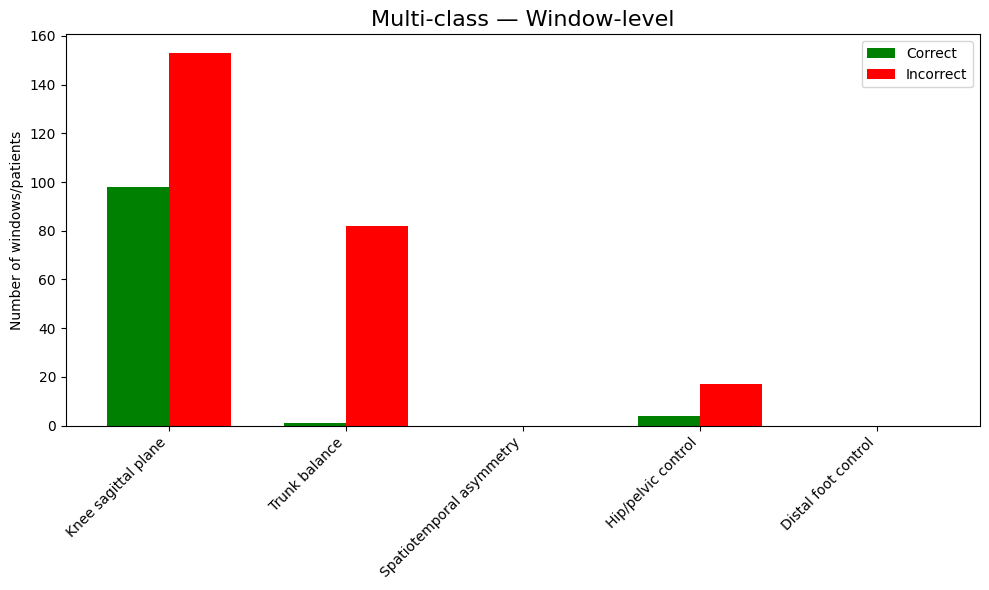

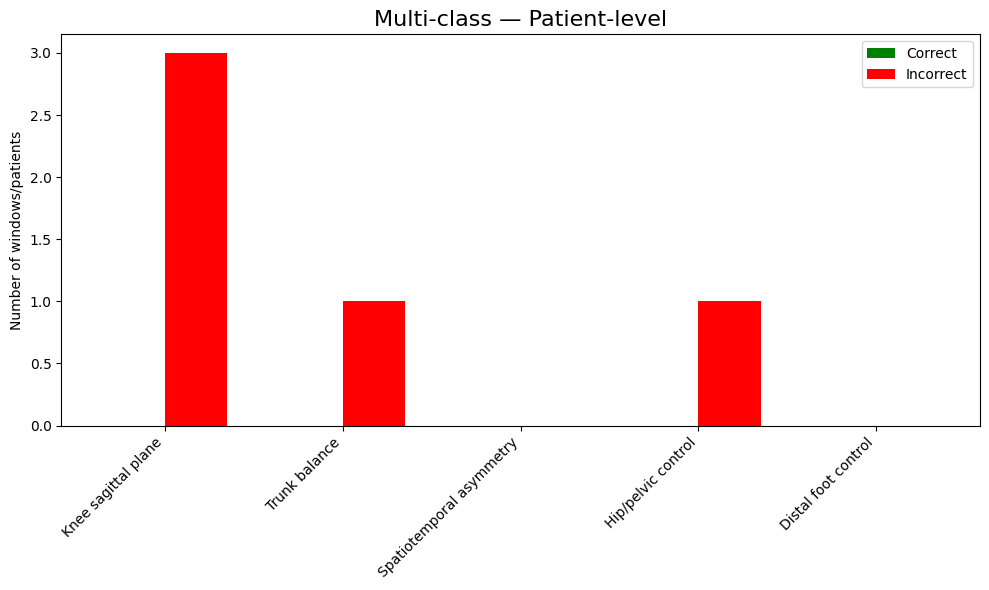

In [63]:
# Window-level
plot_multiclass_bar(cm_window_ml, ANOMALY_LABELS, title="Multi-class — Window-level")

# Patient-level
plot_multiclass_bar(cm_patient_ml, ANOMALY_LABELS, title="Multi-class — Patient-level")


In [188]:
def plot_multiclass_pie_with_totals(
    cm,
    class_names,
    title="Multi-class Pie",
    label_fontsize=16,
    title_fontsize=24,
    correct_radius=1.1,
    incorrect_radius=1.2,
    line_start_radius=0.85,
    show_total=True
):
    """
    Pie chart showing correct vs incorrect predictions per class,
    and optionally showing total percentages across all classes.
    """

    cm = np.asarray(cm)
    num_classes = len(class_names)

    # Counts
    correct = cm.diagonal()
    total = cm.sum(axis=1)
    incorrect = total - correct

    # Build plotting data
    sizes = []
    colors = []
    labels = []
    is_correct_flag = []

    for i in range(num_classes):
        if total[i] == 0:
            continue

        sizes += [correct[i], incorrect[i]]
        colors += ["green", "red"]
        labels += [
            f"{class_names[i]} (correct)",
            f"{class_names[i]} (incorrect)"
        ]
        is_correct_flag += [True, False]

    if sum(sizes) == 0:
        print("No data to plot")
        return

    # Calculate total percentages
    total_correct = correct.sum()
    total_incorrect = incorrect.sum()
    total_acc = total_correct / (total_correct + total_incorrect) * 100
    total_wrong = 100 - total_acc

    if show_total:
        print(f"Total correct: {total_correct} ({total_acc:.1f}%)")
        print(f"Total incorrect: {total_incorrect} ({total_wrong:.1f}%)")

    # Plot pie
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, _ = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )

    # Place labels with independent distances
    for i, w in enumerate(wedges):
        angle = (w.theta1 + w.theta2) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        r_label = correct_radius if is_correct_flag[i] else incorrect_radius
        ha = "left" if x >= 0 else "right"

        ax.text(
            x * r_label,
            y * r_label,
            labels[i],
            ha=ha,
            va="center",
            fontsize=label_fontsize
        )

        # Connector line
        ax.plot(
            [x * line_start_radius, x * r_label],
            [y * line_start_radius, y * r_label],
            color="black",
            lw=0.8
        )

    # Title + layout
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.axis("equal")

    plt.show()


Total correct: 103 (29.0%)
Total incorrect: 252 (71.0%)


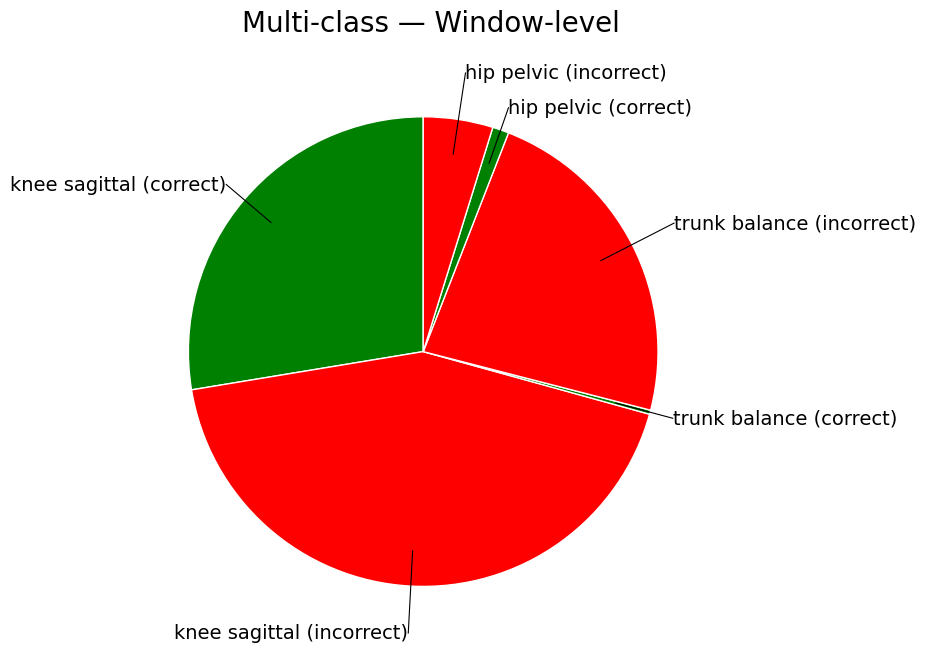

Total correct: 0 (0.0%)
Total incorrect: 5 (100.0%)


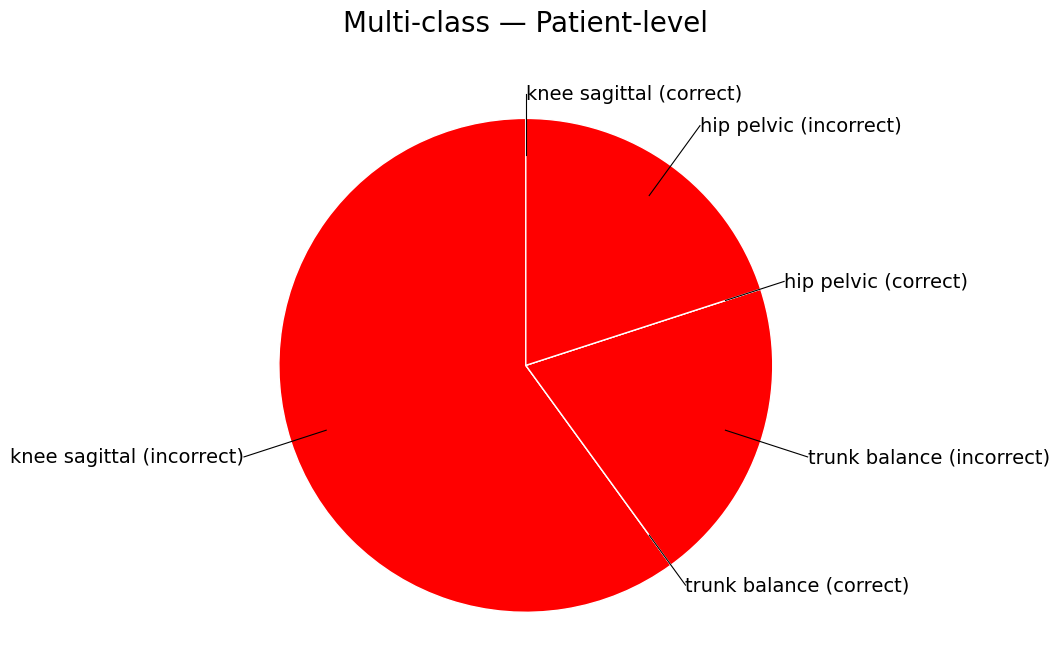

In [189]:
ANOMALY_LABELS = ["knee sagittal", "trunk balance", "spatiotemporal", "hip pelvic", "distal foot"]

# Window-level
plot_multiclass_pie_with_totals(
    cm_window_ml,
    ANOMALY_LABELS,
    title="Multi-class — Window-level",
    label_fontsize=14,
    title_fontsize=20
)

# Patient-level
plot_multiclass_pie_with_totals(
    cm_patient_ml,
    ANOMALY_LABELS,
    title="Multi-class — Patient-level",
    label_fontsize=14,
    title_fontsize=20
)


In [192]:
# now with total percentages shown on the pie chart itself
def plot_multiclass_pie_with_legend(
    cm,
    class_names,
    title="Multi-class Pie",
    label_fontsize=14,
    title_fontsize=20,
    correct_radius=1.1,
    incorrect_radius=1.2,
    line_start_radius=0.85
):
    """
    Pie chart showing correct vs incorrect predictions per class, with a legend
    displaying the total numbers and percentages.
    """
    cm = np.asarray(cm)
    num_classes = len(class_names)

    # Counts
    correct = cm.diagonal()
    total = cm.sum(axis=1)
    incorrect = total - correct

    # Prepare pie data
    sizes = []
    colors = []
    labels = []
    is_correct_flag = []

    for i in range(num_classes):
        if total[i] == 0:
            continue
        sizes += [correct[i], incorrect[i]]
        colors += ["green", "red"]
        labels += [
            f"{class_names[i]} (correct)",
            f"{class_names[i]} (incorrect)"
        ]
        is_correct_flag += [True, False]

    if sum(sizes) == 0:
        print("No data to plot")
        return

    # Overall totals
    total_correct = correct.sum()
    total_incorrect = incorrect.sum()
    total_acc = total_correct / (total_correct + total_incorrect) * 100
    total_wrong = 100 - total_acc

    # Plot pie
    fig, ax = plt.subplots(figsize=(10, 8))
    wedges, _ = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )

    # Place labels for each class slice
    for i, w in enumerate(wedges):
        angle = (w.theta1 + w.theta2) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))
        r_label = correct_radius if is_correct_flag[i] else incorrect_radius
        ha = "left" if x >= 0 else "right"
        ax.text(
            x * r_label,
            y * r_label,
            labels[i],
            ha=ha,
            va="center",
            fontsize=label_fontsize
        )
        # connector line
        ax.plot(
            [x * line_start_radius, x * r_label],
            [y * line_start_radius, y * r_label],
            color="black",
            lw=0.8
        )

    # Legend for colors with total percentages
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="green", edgecolor="white",
              label=f"Total correct: {total_correct} ({total_acc:.1f}%)"),
        Patch(facecolor="red", edgecolor="white",
              label=f"Total incorrect: {total_incorrect} ({total_wrong:.1f}%)")
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=label_fontsize)

    # Title
    ax.set_title(title, fontsize=title_fontsize, pad=20)
    ax.axis("equal")
    plt.show()


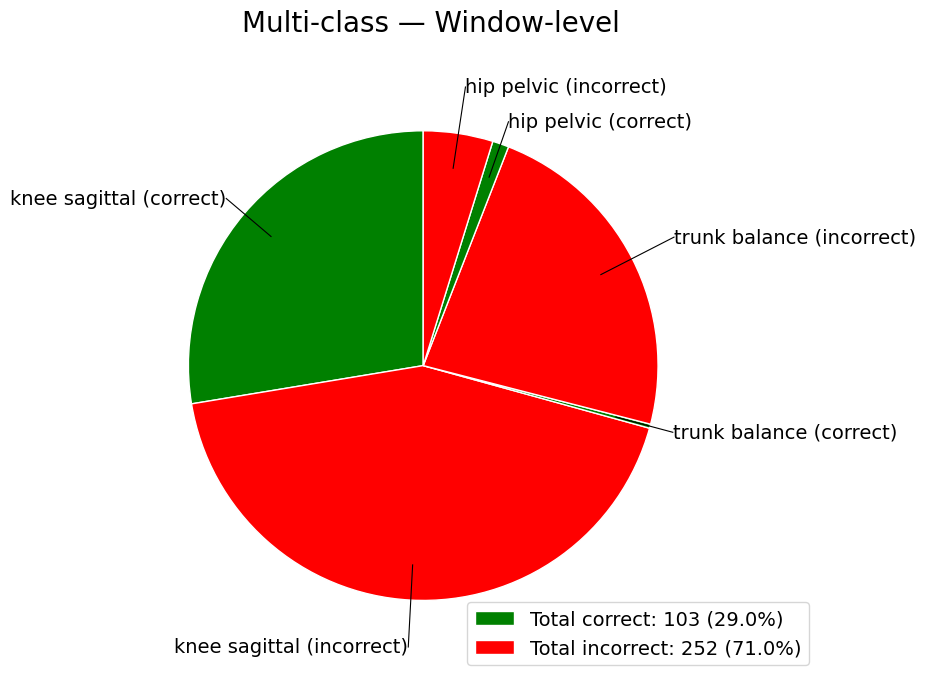

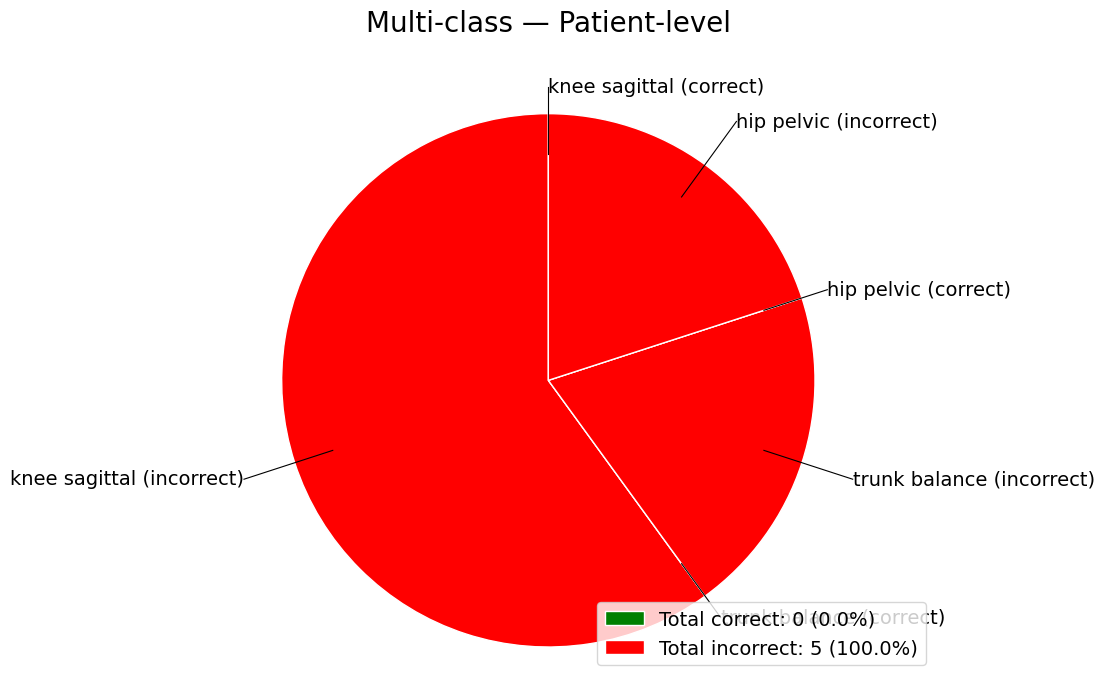

In [193]:
ANOMALY_LABELS = ["knee sagittal", "trunk balance", "spatiotemporal", "hip pelvic", "distal foot"]

# Window-level
plot_multiclass_pie_with_legend(
    cm_window_ml,
    ANOMALY_LABELS,
    title="Multi-class — Window-level"
)

# Patient-level
plot_multiclass_pie_with_legend(
    cm_patient_ml,
    ANOMALY_LABELS,
    title="Multi-class — Patient-level"
)


### Check paths

In [25]:
from pathlib import Path

BINARY_MODEL_PATH = Path("../models/binary_stgcn_gait14_improved_stadedict.bin")
MULTI_MODEL_PATH  = Path("../models/multilabel_stgcn_state_dict.bin")

print("Binary exists?", BINARY_MODEL_PATH.exists())
print("Multi-label exists?", MULTI_MODEL_PATH.exists())


Binary exists? True
Multi-label exists? True


In [24]:
from pathlib import Path

models_folder = Path("../models")
binary_file = models_folder / "binary_stgcn_gait14_improved_statedict.bin"
multi_file = models_folder / "multilabel_stgcn_state_dict.bin"

print("Binary exists?", binary_file.exists())
print("Multi-label exists?", multi_file.exists())

print("Files in models folder:")
for f in models_folder.iterdir():
    print(f.name)


Binary exists? False
Multi-label exists? True
Files in models folder:
pose_landmarker_lite.task
net
.DS_Store
multi_label_abnormal_model.bin
graph.py
.gitkeep
multilabel_stgcn_state_dict.pt
binary_model.bin
binary_stgcn_gait14_improved_stadedict.bin
binary_model_full.bin
binary_stgcn_gait14_stadedict.bin
multi_model.bin
multi_label_model_full.bin
multilabel_stgcn_state_dict.bin


# Load the simple ST-GCN model and plot the results

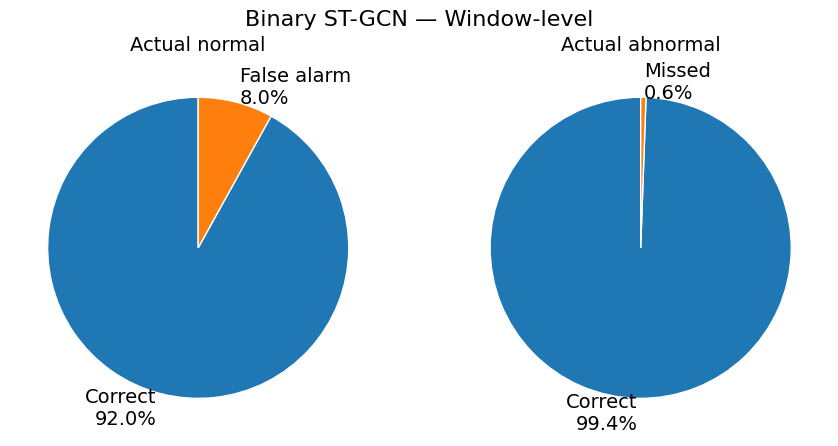

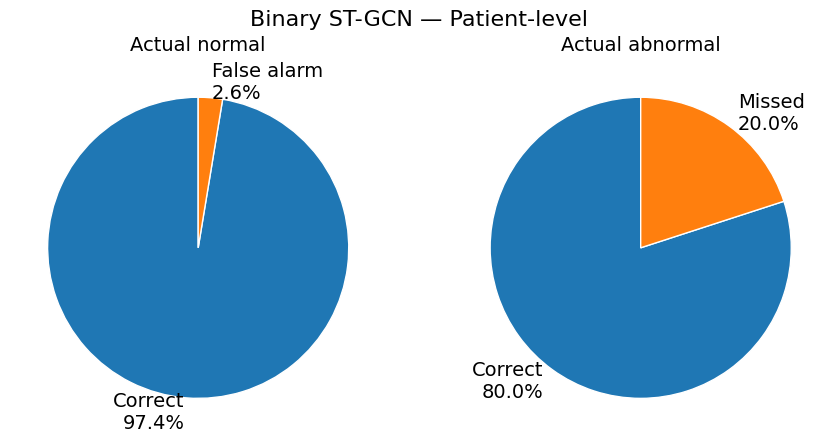

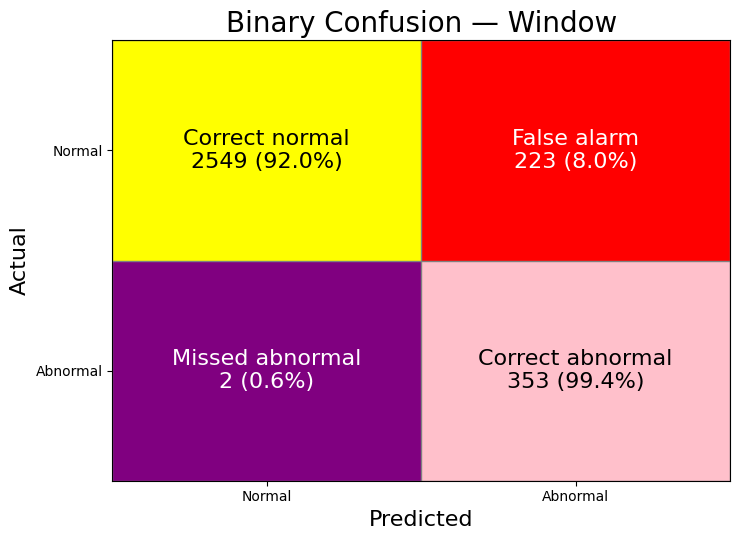

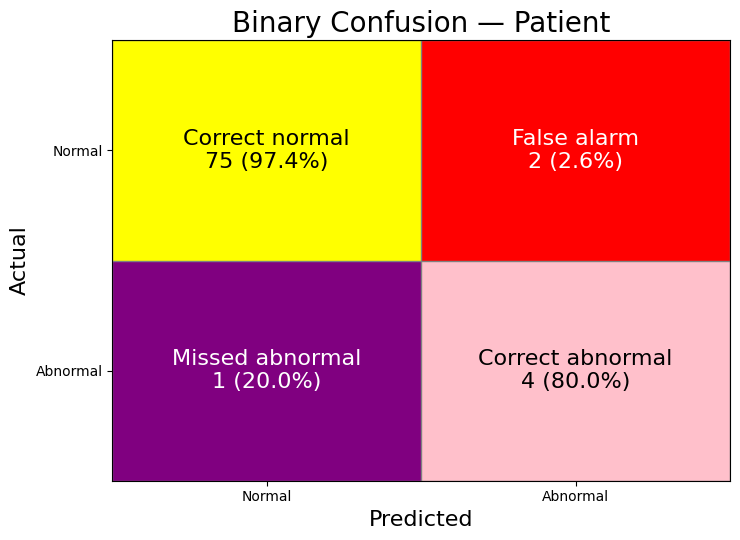

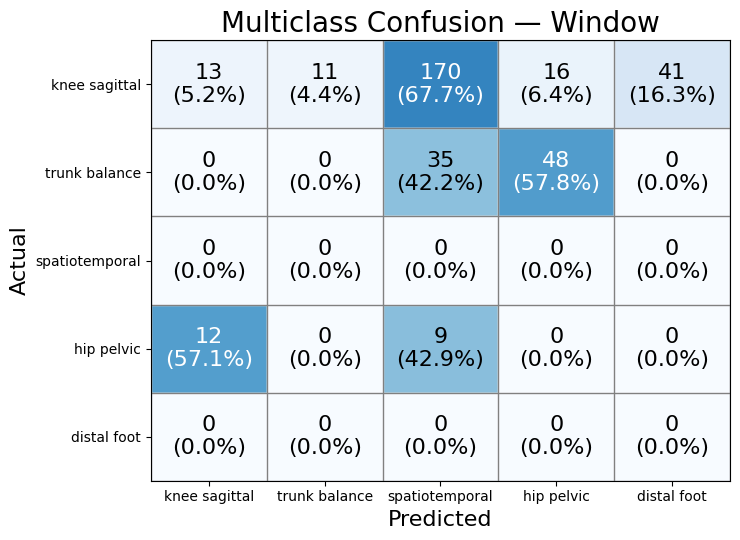

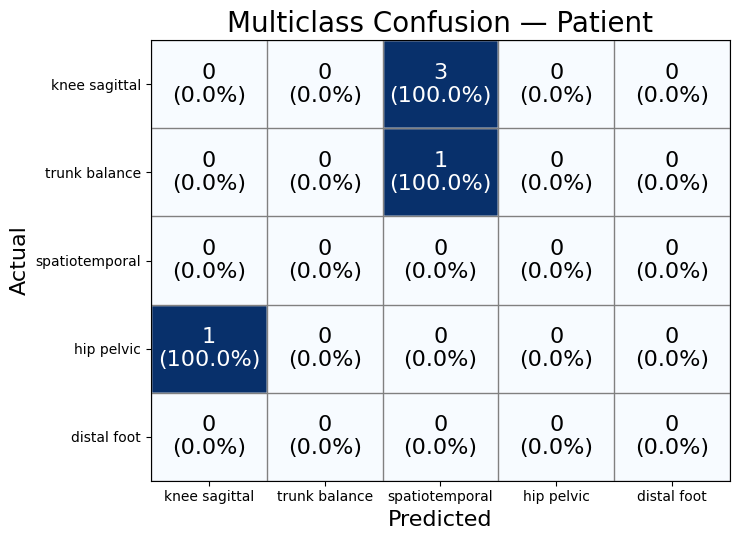

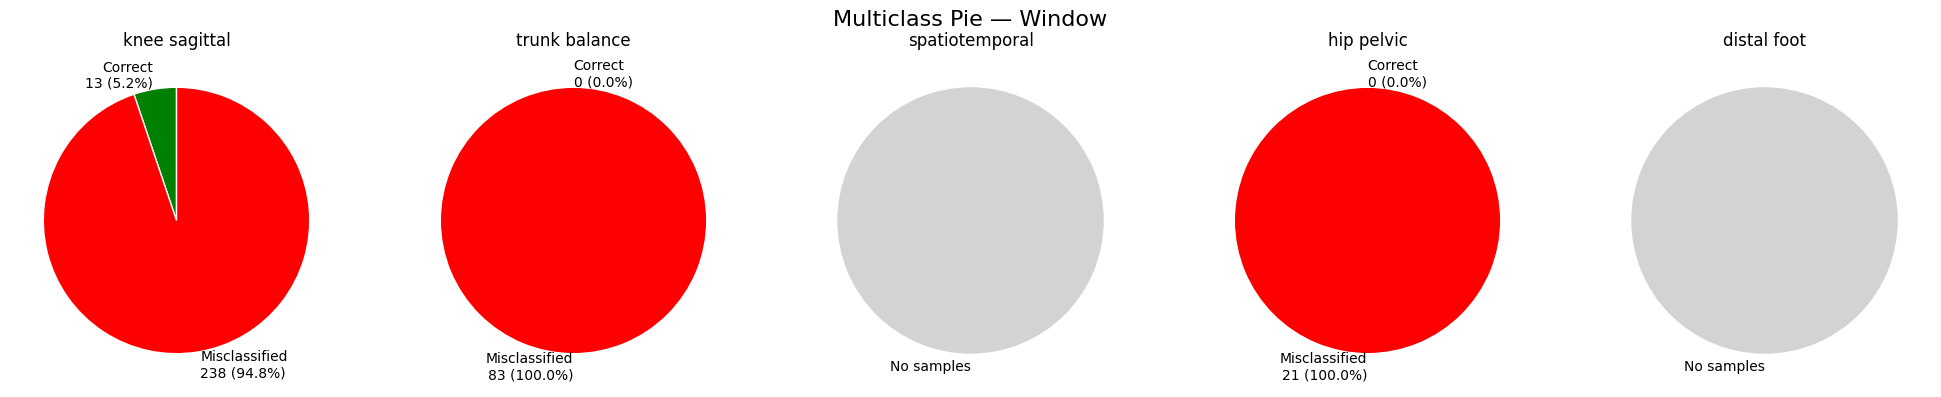

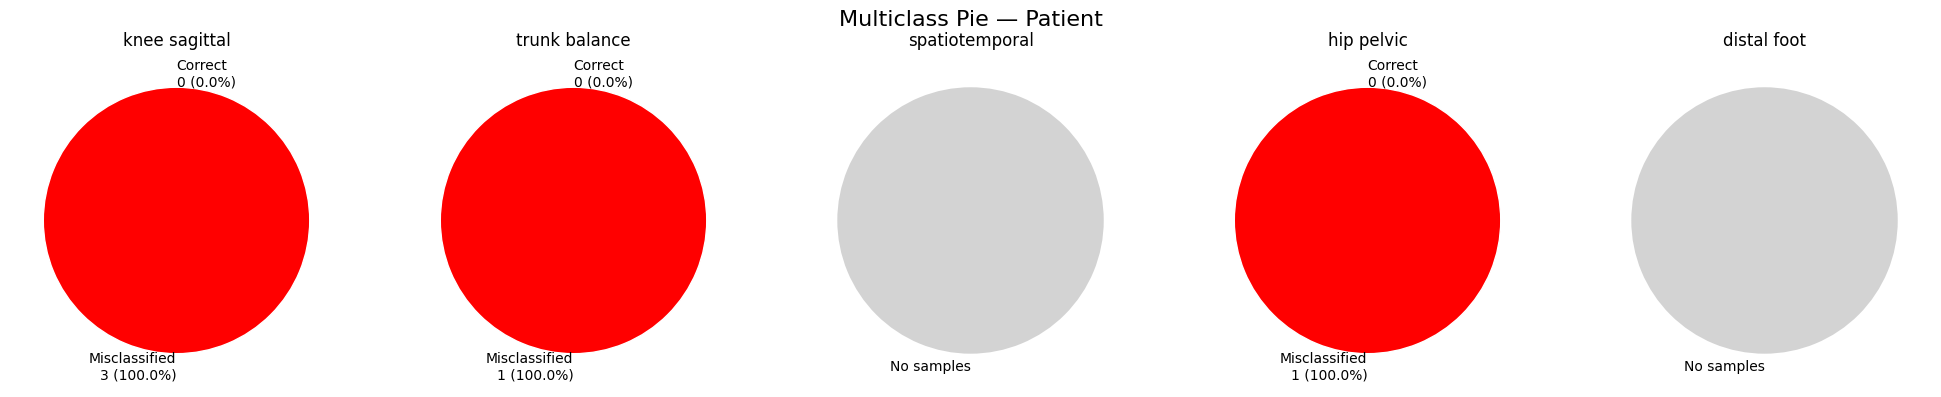

In [181]:
# ============================================================
# FULL SIMPLE-STGCN EVALUATION SCRIPT
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)

# ============================================================
# Device
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Paths
# ============================================================
BINARY_MODEL_PATH = "../models/binary_model_full.bin"
MULTI_MODEL_PATH  = "../models/multi_label_abnormal_model.bin"

# ============================================================
# Simple ST-GCN (must match training exactly)
# ============================================================
class SimpleSTGCN(nn.Module):
    def __init__(self, num_joints, in_channels=3, out_classes=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=(1,1))
        self.conv2 = nn.Conv2d(64, 128, kernel_size=(1,1))
        self.pool = nn.AdaptiveAvgPool2d((1, num_joints))
        self.fc = nn.Linear(128 * num_joints, out_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)

# ============================================================
# Dataset
# ============================================================
class PoseDataset(Dataset):
    def __init__(self, X, y, pids):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32 if y.ndim > 1 else torch.long)
        self.pids = np.asarray(pids)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.pids[idx]

# ============================================================
# ASSUMED AVAILABLE:
# X_clean (N, T, J, 3)
# y_binary_clean (N,)
# y_multilabel_clean (N, 5)
# patient_names_clean (N,)
# ============================================================

from sklearn.model_selection import train_test_split

unique_patients = np.unique(patient_names_clean)
train_p, test_p = train_test_split(unique_patients, test_size=0.2, random_state=42)

test_mask = np.isin(patient_names_clean, test_p)

X_test = X_clean[test_mask]
y_bin_test = y_binary_clean[test_mask]
y_ml_test = y_multilabel_clean[test_mask]
patient_test = patient_names_clean[test_mask]

# ST-GCN format: (N, 3, T, J)
X_test_stgcn = X_test.transpose(0, 3, 1, 2)

# Binary loader
test_loader_bin = DataLoader(
    PoseDataset(X_test_stgcn, y_bin_test, patient_test),
    batch_size=32,
    shuffle=False
)

# ============================================================
# LOAD MODELS
# ============================================================

# ---- Binary (FULL MODEL SAVED)
binary_model = torch.load(BINARY_MODEL_PATH, map_location=device, weights_only=False)
binary_model.eval()

# ---- Multilabel (STATE_DICT ONLY)
num_joints = X_test_stgcn.shape[3]
num_classes = 5  # fixed 5 anomaly classes

multi_model = SimpleSTGCN(num_joints=num_joints, out_classes=num_classes).to(device)
multi_model.load_state_dict(torch.load(MULTI_MODEL_PATH, map_location=device))
multi_model.eval()

# ============================================================
# BINARY EVALUATION
# ============================================================
all_probs, all_targets, all_pids = [], [], []

with torch.no_grad():
    for X, y, p in test_loader_bin:
        X = X.to(device)
        logits = binary_model(X).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y.numpy())
        all_pids.append(p)

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_pids = np.concatenate(all_pids)

window_preds = (all_probs > 0.5).astype(int)
cm_window_bin = confusion_matrix(all_targets, window_preds)

# Patient-level aggregation
patient_preds, patient_probs, patient_true = [], [], []
for pid in np.unique(all_pids):
    idx = all_pids == pid
    patient_probs.append(all_probs[idx].mean())
    patient_preds.append(int(all_probs[idx].mean() > 0.5))
    patient_true.append(int(all_targets[idx].max()))

cm_patient_bin = confusion_matrix(patient_true, patient_preds)

# ============================================================
# MULTILABEL EVALUATION (abnormal only)
# ============================================================
abnormal_mask = y_bin_test == 1
X_ml = X_test_stgcn[abnormal_mask]
y_ml = y_ml_test[abnormal_mask]
p_ml = patient_test[abnormal_mask]

test_loader_ml = DataLoader(PoseDataset(X_ml, y_ml, p_ml), batch_size=32, shuffle=False)

all_probs, all_targets, all_pids = [], [], []

with torch.no_grad():
    for X, y, p in test_loader_ml:
        X = X.to(device)
        probs = torch.sigmoid(multi_model(X))
        all_probs.append(probs.cpu().numpy())
        all_targets.append(y.numpy())
        all_pids.append(p)

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_pids = np.concatenate(all_pids)

# Window-level multiclass
y_true_win = all_targets.argmax(axis=1)
y_pred_win = all_probs.argmax(axis=1)
cm_window_ml = confusion_matrix(y_true_win, y_pred_win, labels=[0,1,2,3,4])

# Patient-level multiclass
patient_preds, patient_true = [], []
for pid in np.unique(all_pids):
    idx = all_pids == pid
    patient_preds.append(all_probs[idx].mean(axis=0).argmax())
    patient_true.append(all_targets[idx][0].argmax())

cm_patient_ml = confusion_matrix(patient_true, patient_preds, labels=[0,1,2,3,4])

# ============================================================
# PLOTTING FUNCTIONS
# ============================================================

def plot_binary_pies(cm, title, title_fontsize=16, label_fontsize=14, subplot_title_fontsize=14):
    """
    Binary pie charts for confusion matrix with adjustable font sizes.
    
    Parameters:
    - cm: 2x2 confusion matrix
    - title: overall figure title
    - title_fontsize: font size of the main title
    - label_fontsize: font size of the labels on the pie slices
    - subplot_title_fontsize: font size of "Actual normal"/"Actual abnormal"
    """
    normal_row = cm[0] / cm[0].sum()
    abnormal_row = cm[1] / cm[1].sum()
    fig, axes = plt.subplots(1,2, figsize=(9,4.5))
    fig.suptitle(title, fontsize=title_fontsize)

    # Actual normal
    axes[0].pie([normal_row[0], normal_row[1]],
                labels=[f"Correct\n{normal_row[0]*100:.1f}%",
                        f"False alarm\n{normal_row[1]*100:.1f}%"],
                startangle=90,
                colors=["#1f77b4","#ff7f0e"],  # blue / orange
                wedgeprops={"edgecolor":"white"},
                textprops={"fontsize": label_fontsize})
    axes[0].set_title("Actual normal", fontsize=subplot_title_fontsize)

    # Actual abnormal
    axes[1].pie([abnormal_row[1], abnormal_row[0]],
                labels=[f"Correct\n{abnormal_row[1]*100:.1f}%",
                        f"Missed\n{abnormal_row[0]*100:.1f}%"],
                startangle=90,
                colors=["#1f77b4","#ff7f0e"],
                wedgeprops={"edgecolor":"white"},
                textprops={"fontsize": label_fontsize})
    axes[1].set_title("Actual abnormal", fontsize=subplot_title_fontsize)

    plt.tight_layout()
    plt.show()



def plot_multiclass_pie(cm, class_names, title="Multi-class Pie"):
    cm = np.asarray(cm)
    num_classes = len(class_names)
    fig, axes = plt.subplots(1,num_classes,figsize=(4*num_classes,4))
    if num_classes==1: axes=[axes]

    for i in range(num_classes):
        correct = cm[i,i]
        total = cm[i].sum()
        incorrect = total - correct
        if total==0:
            axes[i].pie([1], labels=["No samples"], colors=["lightgray"], startangle=90)
        else:
            axes[i].pie([correct, incorrect],
                        labels=[f"Correct\n{correct} ({correct/total*100:.1f}%)",
                                f"Misclassified\n{incorrect} ({incorrect/total*100:.1f}%)"],
                        startangle=90,
                        colors=["green","red"],
                        wedgeprops={"edgecolor":"white"})
        axes[i].set_title(class_names[i])
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_custom(cm, class_names, title="Confusion Matrix",
                                 title_fontsize=20, axis_labelsize=16, tick_labelsize=10):
    """
    Confusion matrix with:
    - custom colors for binary (4 colors)
    - gradient for multi-class
    - percentages shown inside cells
    - adjustable font sizes for title, axes, and tick labels
    """
    cm = np.asarray(cm)
    num_classes = len(class_names)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = cm / np.maximum(row_sums,1) * 100
    fig, ax = plt.subplots(figsize=(7.5,5.5))

    if num_classes==2:
        # Binary: 4 colors
        colors = np.array([["yellow", "red"],["purple", "pink"]])
        for i in range(2):
            for j in range(2):
                ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,facecolor=colors[i,j]))
                count = cm[i,j]; pct=row_pct[i,j]
                if i==0 and j==0: label=f"Correct normal\n{count} ({pct:.1f}%)"
                elif i==0 and j==1: label=f"False alarm\n{count} ({pct:.1f}%)"
                elif i==1 and j==0: label=f"Missed abnormal\n{count} ({pct:.1f}%)"
                else: label=f"Correct abnormal\n{count} ({pct:.1f}%)"
                text_color = "black" if colors[i,j] in ["yellow", "pink"] else "white"
                ax.text(j,i,label,ha="center",va="center",fontsize=16,color=text_color)
    else:
        # Multi-class gradient
        cmap = plt.cm.Blues
        for i in range(num_classes):
            for j in range(num_classes):
                ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,
                                           facecolor=cmap(row_pct[i,j]/100),
                                           edgecolor='white'))
                count=cm[i,j]; pct=row_pct[i,j]
                ax.text(j,i,f"{count}\n({pct:.1f}%)",ha="center",va="center",
                        fontsize=16,color="white" if row_pct[i,j]>50 else "black")

    ax.set_xlim(-0.5,num_classes-0.5)
    ax.set_ylim(-0.5,num_classes-0.5)
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, fontsize=tick_labelsize)
    ax.set_yticklabels(class_names, fontsize=tick_labelsize)
    ax.set_xlabel("Predicted", fontsize=axis_labelsize)
    ax.set_ylabel("Actual", fontsize=axis_labelsize)
    ax.set_title(title, fontsize=title_fontsize)
    ax.invert_yaxis()
    ax.set_xticks(np.arange(-.5,num_classes,1),minor=True)
    ax.set_yticks(np.arange(-.5,num_classes,1),minor=True)
    ax.grid(which="minor",linestyle="-",linewidth=1,color="gray")
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    return fig, ax


# ============================================================
# PLOTTING
# ============================================================

# Binary
plot_binary_pies(cm_window_bin, "Binary ST-GCN — Window-level")
plot_binary_pies(cm_patient_bin, "Binary ST-GCN — Patient-level")
plot_confusion_matrix_custom(cm_window_bin, ["Normal","Abnormal"], "Binary Confusion — Window")
plot_confusion_matrix_custom(cm_patient_bin, ["Normal","Abnormal"], "Binary Confusion — Patient")

# Multiclass
labels = ["knee sagittal", "trunk balance", "spatiotemporal", "hip pelvic", "distal foot"]
plot_confusion_matrix_custom(cm_window_ml, labels, "Multiclass Confusion — Window")
plot_confusion_matrix_custom(cm_patient_ml, labels, "Multiclass Confusion — Patient")
plot_multiclass_pie(cm_window_ml, labels, "Multiclass Pie — Window")
plot_multiclass_pie(cm_patient_ml, labels, "Multiclass Pie — Patient")


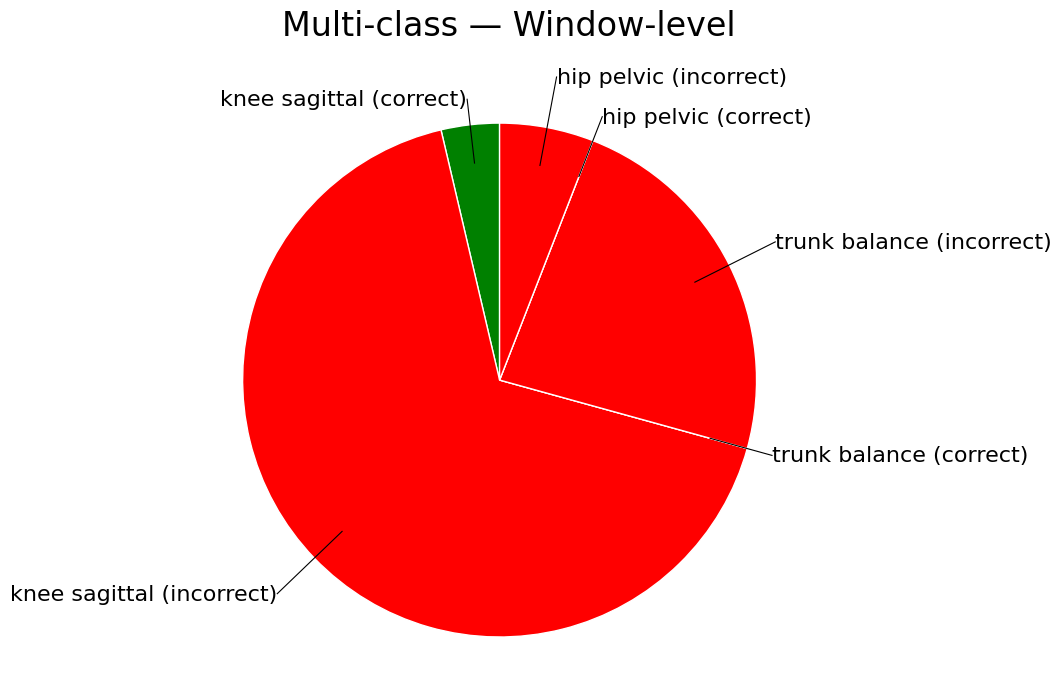

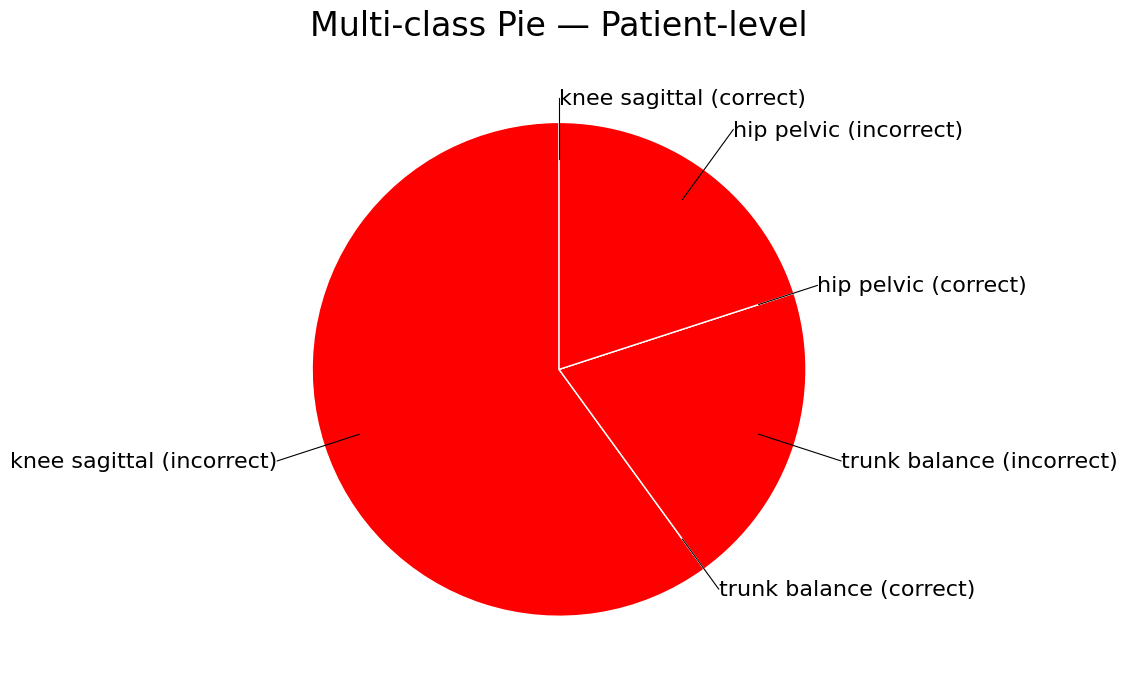

In [160]:
# plot the pie chart for multi-classes
ANOMALY_LABELS = [
    "knee sagittal",
    "trunk balance",
    "spatiotemporal",
    "hip pelvic",
    "distal foot"
]

plot_multiclass_pie_separated_labels(
    cm_window_ml,
    ANOMALY_LABELS,
    title="Multi-class — Window-level",
    label_fontsize=16,
    title_fontsize=24
)

# Patient-level
plot_multiclass_pie_separated_labels(
    cm_patient_ml,
    ANOMALY_LABELS,
    title="Multi-class Pie — Patient-level",
    label_fontsize=16,
    title_fontsize=24
)


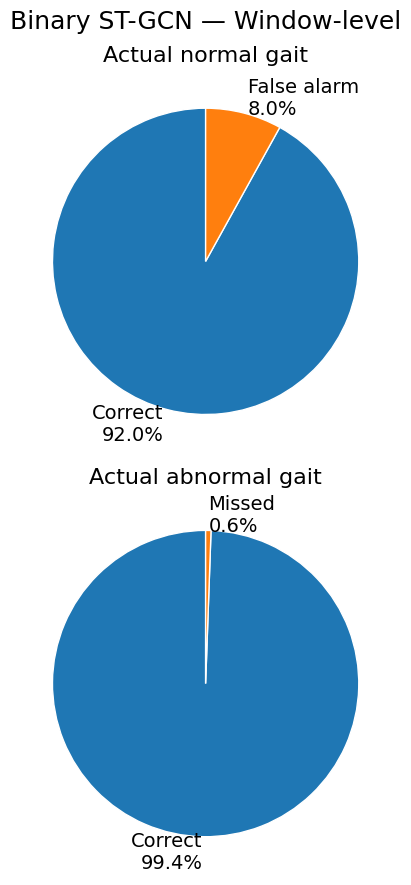

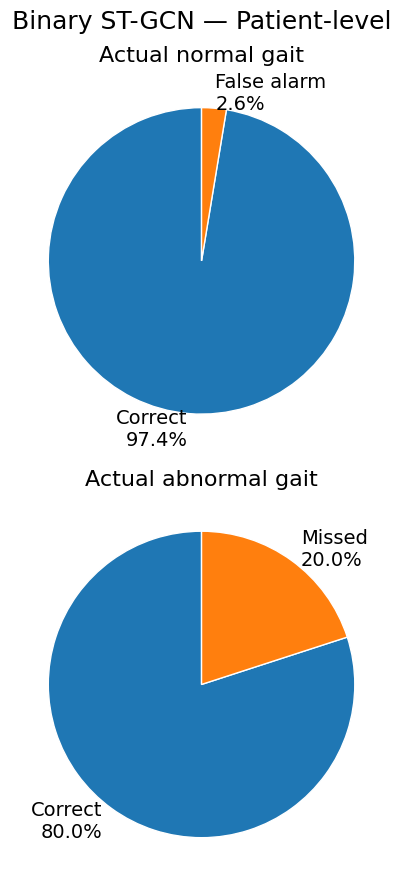

In [182]:
# Window-level binary confusion matrix
plot_out_of_100_pies(
    cm_window_bin, 
    title="Binary ST-GCN — Window-level",
    suptitle_fontsize=18,
    slice_label_fontsize=14,
    subplot_title_fontsize=16
)

# Patient-level binary confusion matrix
plot_out_of_100_pies(
    cm_patient_bin, 
    title="Binary ST-GCN — Patient-level",
    suptitle_fontsize=18,
    slice_label_fontsize=14,
    subplot_title_fontsize=16
)

In [209]:
def plot_multiclass_predicted_pie_from_cm(
    cm,
    class_names,
    title="Multiclass: predicted classes • accuracy per predicted class",

    # ---- distance controls ----
    text_radius=1.45,
    anchor_radius=1.02,
    text_x_offset=1.55,

    # ---- font controls ----
    label_fontsize=25,
    title_fontsize=28,
    legend_fontsize=24,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Wedge, Patch
    from matplotlib.colors import to_rgba

    cm = np.asarray(cm)

    pred_counts = cm.sum(axis=0)
    correct = np.diag(cm)
    incorrect = pred_counts - correct

    mask = pred_counts > 0
    pred_counts = pred_counts[mask]
    correct = correct[mask]
    incorrect = incorrect[mask]
    class_names = [c for c, m in zip(class_names, mask) if m]

    total = pred_counts.sum()
    class_fracs = pred_counts / total
    acc_predclass = correct / pred_counts

    order = np.argsort(pred_counts)[::-1]
    pred_counts = pred_counts[order]
    correct = correct[order]
    incorrect = incorrect[order]
    class_fracs = class_fracs[order]
    acc_predclass = acc_predclass[order]
    class_names = [class_names[i] for i in order]

    palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    class_colors = [palette[i % len(palette)] for i in range(len(class_names))]

    sizes, colors, is_incorrect = [], [], []
    for i, col in enumerate(class_colors):
        base = to_rgba(col)
        sizes += [correct[i], incorrect[i]]
        colors += [(base[0], base[1], base[2], 0.95),
                   (base[0], base[1], base[2], 0.95)]
        is_incorrect += [False, True]

    fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)

    wedges, _ = ax.pie(
        sizes,
        startangle=90,
        colors=colors,
        labels=[""] * len(sizes),
        wedgeprops=dict(edgecolor="white", linewidth=1.3),
    )

    for w, inc in zip(wedges, is_incorrect):
        if inc:
            w.set_hatch("////")
            w.set_edgecolor("black")
            w.set_linewidth(1.1)

    # Thick class borders
    theta = 90
    for n in pred_counts:
        ang = n / total * 360
        ax.add_patch(Wedge(
            (0, 0), 1.0, theta, theta + ang,
            facecolor="none", edgecolor="black", linewidth=3.4
        ))
        theta += ang

    # ---------- label placement ----------
    def repel(y, min_sep=0.14, low=-1.1, high=1.1):
        y = y.copy()
        for i in range(1, len(y)):
            if y[i] - y[i-1] < min_sep:
                y[i] = y[i-1] + min_sep
        return np.clip(y, low, high)

    theta = 90
    mids = []
    for frac in class_fracs:
        ang = frac * 360
        mids.append(np.deg2rad(theta + ang / 2))
        theta += ang
    mids = np.array(mids)

    y0 = text_radius * np.sin(mids)
    right = np.where(np.cos(mids) >= 0)[0]
    left  = np.where(np.cos(mids) < 0)[0]

    y_r = repel(y0[right])
    y_l = repel(y0[left])

    def place(i, y):
        ha = "left" if np.cos(mids[i]) >= 0 else "right"
        x_text = text_x_offset if ha == "left" else -text_x_offset

        ax.annotate(
            f"{class_names[i]}  {acc_predclass[i]*100:.1f}%",
            xy=(anchor_radius*np.cos(mids[i]), anchor_radius*np.sin(mids[i])),
            xytext=(x_text, y),
            ha=ha, va="center",
            fontsize=label_fontsize,
            arrowprops=dict(arrowstyle="-", lw=1.6),
        )

    for i, y in zip(right, y_r): place(i, y)
    for i, y in zip(left,  y_l): place(i, y)

    ax.legend(
        handles=[
            Patch(facecolor="black", label="correct"),
            Patch(facecolor="white", hatch="////", edgecolor="black", label="incorrect"),
        ],
        fontsize=legend_fontsize,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=2,
        frameon=False
    )

    ax.set(aspect="equal")
    ax.set_title(title, fontsize=title_fontsize, pad=14)
    plt.show()


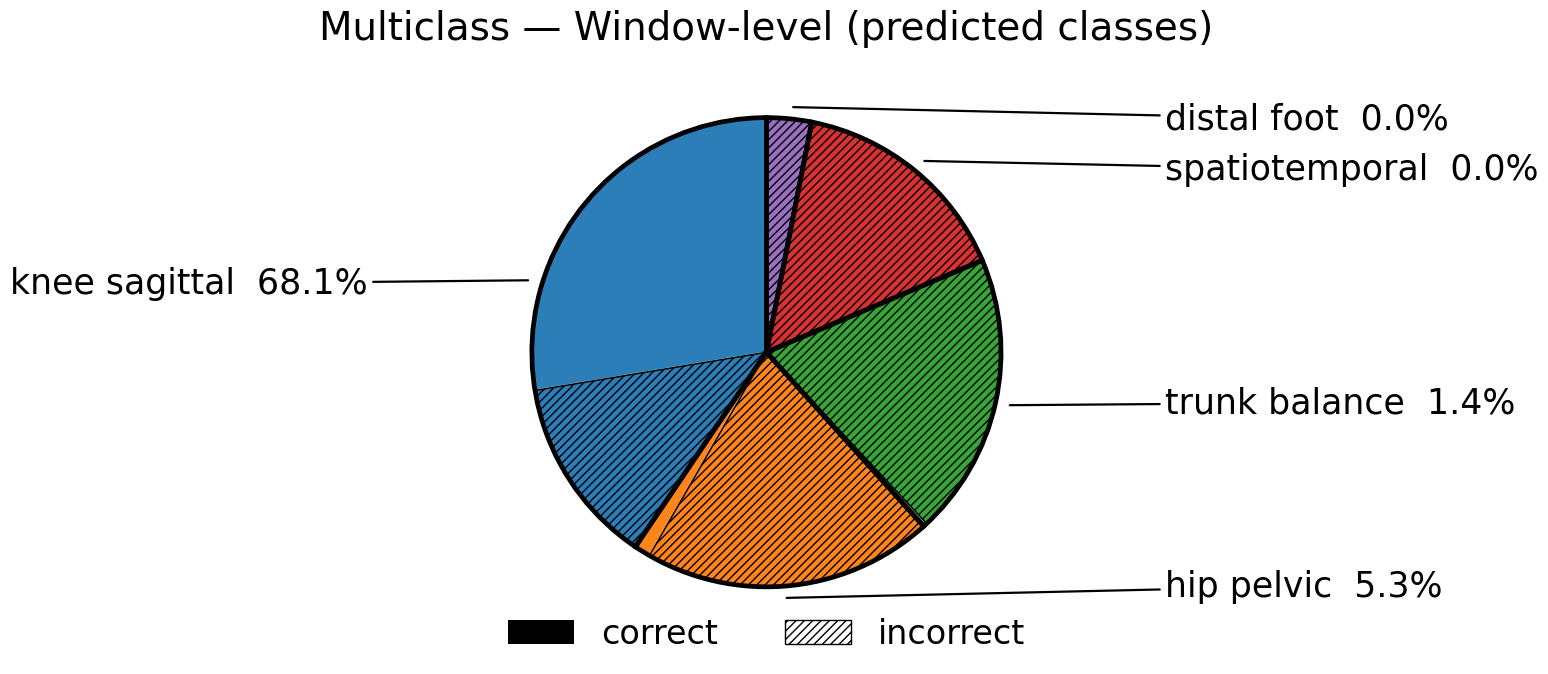

In [213]:
plot_multiclass_predicted_pie_from_cm(
    cm_window_ml,
    ANOMALY_LABELS,
    title="Multiclass — Window-level (predicted classes)",
    text_radius=1.0,
    anchor_radius=1.05,
    text_x_offset=1.7
)


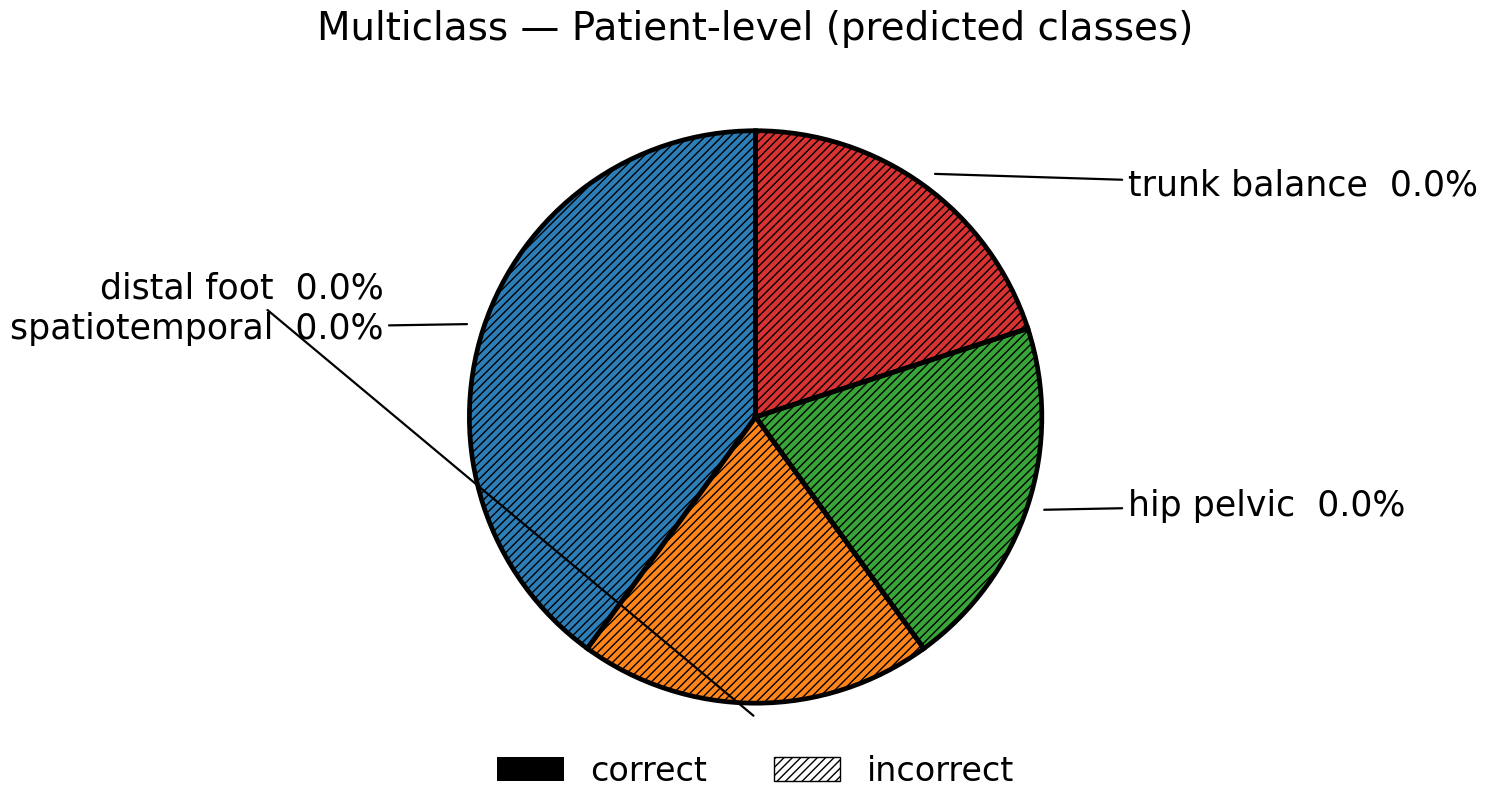

In [216]:
plot_multiclass_predicted_pie_from_cm(
    cm_patient_ml,
    ANOMALY_LABELS,
    title="Multiclass — Patient-level (predicted classes)",
    text_radius=1.0,
    anchor_radius=1.05,
    text_x_offset=1.3
)
